# Line Emission Denoising: Sweep-Winner Validation + Artifact Diagnostics

## 0. Bootstrap (clone repo for `src/`, locate data)

In [1]:
import os, sys, subprocess, glob

ON_KAGGLE = os.path.exists('/kaggle')
if ON_KAGGLE:
    REPO='/kaggle/working/EXXA'; PKG=os.path.join(REPO,'DENOISING_DIFFUSION')
    if not os.path.exists(REPO):
        subprocess.run(['git','clone','--branch','midterm-prep','--depth','1','https://github.com/KrishanYadav333/EXXA.git',REPO], check=True)
    else:
        subprocess.run(['git','-C',REPO,'fetch','origin','midterm-prep'], check=True)
        # FETCH_HEAD, not origin/midterm-prep: the clone above is --depth 1 --branch,
        # which implies --single-branch, so the refspec only ever tracks the cloned
        # branch and no origin/midterm-prep ref exists to reset onto.
        subprocess.run(['git','-C',REPO,'reset','--hard','FETCH_HEAD'], check=True)
    # pytorch-msssim for the SSIM loss; bettermoments for moment-map evaluation (Sec. 6)
    subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps','pytorch-msssim','bettermoments'], check=True)
    os.chdir(os.path.join(PKG,'notebooks'));  sys.path.insert(0, PKG)
    # find the line-emission data dir under /kaggle/input (contains run_* subfolders)
    # Fail here, loudly, if the dataset is not attached. Returning None instead
    # defers the error to the first os.path.join two cells later, where it reads as
    # "TypeError: expected str ... not NoneType" and says nothing about the cause.
    hits = (glob.glob('/kaggle/input/**/*_dirty.fits', recursive=True)
            or glob.glob('/kaggle/input/**/*dirty*.fits', recursive=True))
    if not hits:
        avail = sorted(glob.glob('/kaggle/input/*'))
        raise FileNotFoundError(
            'No *_dirty.fits found under /kaggle/input.\n'
            'The line-emission Dataset is probably not attached: '
            'Add Input -> Datasets -> your line-emission cubes.\n'
            f'Currently attached: {avail if avail else "(nothing)"}')
    DATA_DIR = os.path.dirname(os.path.dirname(hits[0]))
else:
    if os.path.basename(os.getcwd()) != 'notebooks' and os.path.isdir('notebooks'): os.chdir('notebooks')
    sys.path.insert(0, os.path.abspath('..'))
    DATA_DIR = '../data/Line Emission Data'
print('cwd:', os.getcwd(), '| DATA_DIR:', DATA_DIR)

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5316/5316), done.


cwd: /kaggle/working/EXXA/DENOISING_DIFFUSION/notebooks | DATA_DIR: /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data


## 0b. Pull latest code (re-run anytime, NO kernel restart needed)

In [2]:
# Pull latest from the midterm-prep branch and hot-reload src/ (no kernel restart).
import os, sys, subprocess

ON_KAGGLE = os.path.exists('/kaggle')
REPO = '/kaggle/working/EXXA'

if ON_KAGGLE and os.path.exists(REPO):
    subprocess.run(['git', '-C', REPO, 'fetch', 'origin', 'midterm-prep'], check=True)
    # FETCH_HEAD, not origin/midterm-prep -- see the bootstrap cell: a --single-branch
    # clone has no remote-tracking ref for any other branch.
    subprocess.run(['git', '-C', REPO, 'reset', '--hard', 'FETCH_HEAD'], check=True)
    print(subprocess.run(['git', '-C', REPO, 'log', '--oneline', '-1'],
                         capture_output=True, text=True).stdout.strip())
elif ON_KAGGLE:
    print('repo not cloned yet -- run the bootstrap cell (0.) first')

for _m in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]
print('src.* cleared from module cache -- now re-run the imports cell below.')

From https://github.com/KrishanYadav333/EXXA
 * branch            midterm-prep -> FETCH_HEAD


HEAD is now at 6f5c798 fix(nb05): section 7 CSV write drops the whole diagnostic over one missing column
6f5c798 fix(nb05): section 7 CSV write drops the whole diagnostic over one missing column
src.* cleared from module cache -- now re-run the imports cell below.


## 1. Imports, device, config

In [3]:
import math, time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.data.cube_split import split_cubes
from src.data.fits_cube_dataset import FITSChannelDataset, continuum_of
from src.models.unet import UNet
from src.training.sweep import train_unet, val_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU  = torch.cuda.device_count()
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('device:', device, '| GPUs:', N_GPU,
      '->', [torch.cuda.get_device_name(i) for i in range(N_GPU)] if N_GPU else 'cpu')

OUT_DIR     = '../results'   # hoisted: section 4 writes its per-seed CSV here too
os.makedirs(OUT_DIR, exist_ok=True)

TARGET_SIZE = 256
N_SAMPLES   = 150     # 08's ACTUAL value (its own comment claiming 256 was wrong -- 256 >
                      # 201, the cube's channel count, and would crash sample_channel_indices).
                      # V12 and the sweep used 50; their PSNR is therefore NOT comparable
                      # to anything here, which the tables already flag. The moment-map
                      # scores ARE comparable -- they are computed on full holdout cubes
                      # and do not depend on how many channels were sampled for training.
NW          = 4 if ON_KAGGLE else 0   # FITS I/O bottleneck; workers help on Kaggle

# V12 reference (fixed 30-epoch run) -- the bar this notebook is measured against
V12 = {'psnr': 32.95, 'ssim': 0.9857, 'mse': 0.000681,
       'M0': (69.8, 15.2), 'M1': (17.5, 7.8), 'M2': (20.1, 14.3)}
# Sweep winner as scored during the sweep (results/sweep_results.csv, run 7)
SWEEP_WINNER_PSNR = 37.109

device: cuda | GPUs: 2 -> ['Tesla T4', 'Tesla T4']


## 2. Cube-level split (3 RunID groups held out for inference only)

In [4]:
train_cubes, val_cubes, holdout_cubes = split_cubes(data_dir=DATA_DIR, n_holdout=3,
                                                     val_fraction=0.2, seed=SEED)

CUBE-LEVEL SPLIT (grouped by RunID — no channel-level leakage)
  data_dir          : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
  total cubes       : 14  across 11 distinct RunIDs
  seed=42  n_holdout=3  val_fraction=0.2
----------------------------------------------------------------------
  TRAIN   :  7 cubes | RunIDs ['0006', '0010', '0020', '0022', '0030', '0035']
  VAL     :  2 cubes | RunIDs ['0016', '0036']
  HOLDOUT :  5 cubes | RunIDs ['0002', '0025', '0026']  <-- inference only, NEVER trained/validated
----------------------------------------------------------------------
  HOLDOUT cube folders (reserved for moment-map evaluation):
    - run_0002_00560_rt_00
    - run_0002_00560_rt_01
    - run_0002_00560_rt_04
    - run_0025_01000_rt_04
    - run_0026_00005_rt_04


## 3. Datasets (full-image 256×256, continuum-subtracted, shared dirty-scale norm)

In [5]:
SUBTRACT_CONTINUUM = True
CONTINUUM_N        = 5
train_ds = FITSChannelDataset(train_cubes, n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
                              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N)
val_ds   = FITSChannelDataset(val_cubes,   n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
                              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N)
# D4-augmented view of the SAME cubes. Notebook 08 measured this as the best arm it
# tried -- +1.3 dB over the un-augmented winner, the best M0/M1/M2 of any arm, and the
# lowest invented-structure rate (29.7% vs 39.0%). With only 6 training disks, the eight
# lossless orientations are the cheapest way to add variety that costs no new data.
train_ds_aug = FITSChannelDataset(train_cubes, n_samples=N_SAMPLES, target_size=TARGET_SIZE,
                                  seed=SEED, subtract_continuum=SUBTRACT_CONTINUUM,
                                  continuum_n=CONTINUUM_N, augment=True)
print('train items:', len(train_ds), '| val items:', len(val_ds))

# Augmentation must vary the TRAIN item and leave VAL deterministic. Wired the wrong way
# round it silently makes validation non-reproducible, which reads as seed noise.
_n_orient = len({train_ds_aug[0][0].numpy().tobytes() for _ in range(40)})
_val_fixed = len({val_ds[0][0].numpy().tobytes() for _ in range(5)}) == 1
print(f'augmented item takes {_n_orient} orientations | val deterministic: {_val_fixed}')
assert _n_orient > 1 and _val_fixed, 'augmentation wiring is wrong -- stop and fix'

# ---- beam-conditioned view (v15's arm, rebuilt) ------------------------------
# Same cubes; each item gains the 4-vector [sin2BPA, cos2BPA, bmaj", bmin"] read from the
# DIRTY header. v15 found this a NEGATIVE result on the unmasked metric (see section 4);
# it is re-tested here because the masked metric is a different measurement, not because
# the earlier answer is doubted.
train_ds_beam = FITSChannelDataset(train_cubes, n_samples=N_SAMPLES, target_size=TARGET_SIZE,
                                   seed=SEED, subtract_continuum=SUBTRACT_CONTINUUM,
                                   continuum_n=CONTINUUM_N, return_beam=True)
val_ds_beam   = FITSChannelDataset(val_cubes, n_samples=N_SAMPLES, target_size=TARGET_SIZE,
                                   seed=SEED, subtract_continuum=SUBTRACT_CONTINUUM,
                                   continuum_n=CONTINUUM_N, return_beam=True)

# ---- patch view --------------------------------------------------------------
# The DDPM's answer to a small training set: 6 disks cannot become more disks, but each
# channel becomes many distinct local structures -- ring edge, cavity, background, line
# core -- which is what a denoiser actually models. Denoising is local, so a patch is not
# a degraded sample of the problem.
from src.data.patches import FlatPatchDataset
PATCH_SIZE, N_PATCHES, PATCH_SIGNAL_BIAS = 64, 8, 0.5
train_ds_patch = FlatPatchDataset(train_ds, patch_size=PATCH_SIZE, n_patches=N_PATCHES,
                                  seed=SEED, signal_bias=PATCH_SIGNAL_BIAS)
val_ds_patch   = FlatPatchDataset(val_ds, patch_size=PATCH_SIZE, n_patches=N_PATCHES,
                                  seed=SEED, signal_bias=PATCH_SIGNAL_BIAS)

# ---- native-600 view ---------------------------------------------------------
# Every arm above trains at 256 and the moments are scored at 600, so a 600->256->600 round
# trip caps every number this notebook reports. This trains at the native size instead.
NATIVE_SIZE = 600
train_ds_600 = FITSChannelDataset(train_cubes, n_samples=N_SAMPLES, target_size=NATIVE_SIZE,
                                  seed=SEED, subtract_continuum=SUBTRACT_CONTINUUM,
                                  continuum_n=CONTINUUM_N)
val_ds_600   = FITSChannelDataset(val_cubes, n_samples=N_SAMPLES, target_size=NATIVE_SIZE,
                                  seed=SEED, subtract_continuum=SUBTRACT_CONTINUUM,
                                  continuum_n=CONTINUUM_N)

print('\ntraining views:')
print('  full-image 256 : {:>6,} samples'.format(len(train_ds)))
print('  augmented 256  : {:>6,} samples (same items, 8 orientations each)'.format(len(train_ds_aug)))
print('  beam 256       : {:>6,} samples + 4-vector'.format(len(train_ds_beam)))
print('  patches {}px   : {:>6,} samples ({} per channel)'.format(
    PATCH_SIZE, len(train_ds_patch), N_PATCHES))
print('  native {}     : {:>6,} samples'.format(NATIVE_SIZE, len(train_ds_600)))

[FITSChannelDataset] 7 cubes x ~150 channels = 1050 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 2 cubes x ~150 channels = 300 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 7 cubes x ~150 channels = 1050 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels) | D4 augmentation ON
train items: 1050 | val items: 300
augmented item takes 8 orientations | val deterministic: True
[FITSChannelDataset] 7 cubes x ~150 channels = 1050 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 2 cubes x ~150 channels = 300 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 7 cubes x ~150 channels = 1050 items | target 600x600 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 2 cubes x ~150 channels = 300 items | target 600x600 | continuum-subtracted (mean o

## 4. Train all three configurations across the same three seeds
### What earlier versions settled, and is therefore not re-run here

In [6]:
import csv, glob, shutil

# The ACTUAL V12 checkpoint, not a retrain of its config. Notebook 05 Version 12 wrote
# ../results/checkpoints/unet_line_emission_continuum_best.pth (epoch 28, val_loss 0.0034)
# inside /kaggle/working, so it is part of that version's Output: attach it as an Input and
# it is restored here. V12 trained on the same 350/100 items this notebook uses, so scoring
# it under the current metric is a like-for-like comparison, not an approximation.
V12_CKPT = os.path.join('../results/checkpoints', 'unet_line_emission_continuum_best.pth')
# Found by ARCHITECTURE, not by filename.
#
# The checkpoint cannot simply be attached. Kaggle's Add Input offers a notebook's LATEST
# output with no version selector, and this notebook's latest is v18 -- the V12 checkpoint
# is in Version 12's output, which is a separate artifact. So it has to be downloaded and
# re-uploaded, and a '.pth' uploaded as a DATASET is unpacked by Kaggle into a directory
# torch.load rejects (RULES.md #3), so it must arrive under a neutral extension. The old
# glob matched one literal filename and would have reported "not available" either way,
# with no hint that the NAME was the problem.
if ON_KAGGLE and not os.path.exists(V12_CKPT):
    _cands = sorted(set(glob.glob('/kaggle/input/**/*.pth', recursive=True)) |
                    set(glob.glob('/kaggle/input/**/*.ckpt', recursive=True)) |
                    set(glob.glob('/kaggle/input/**/*.bin', recursive=True)))
    _hits = []
    # Exclude '*_seed*' -- that is notebook 08's naming, and its v12 arm retrains the V12
    # CONFIG at base 32 / (1,2,4), which is V12's own architecture. The shape test below
    # therefore cannot tell an 08 retrain from the original, and picking one prints it as
    # 'V12 ORIGINAL' while that same checkpoint is already in the v12_cfg band above:
    # one model, two rows, one of them a lie. Section 4's markdown is right that no
    # original V12 checkpoint survives, so finding nothing here is the correct outcome.
    for _h in [c for c in _cands
               if os.path.isfile(c) and '_seed' not in os.path.basename(c)]:
        try:
            _c = torch.load(_h, map_location='cpu', weights_only=False)
        except Exception as _e:
            print('  unreadable, skipped:', os.path.basename(_h), '--', _e)
            continue
        # V12's architecture: base 32, multipliers (1,2,4). The winner arms are base 48
        # with (1,2,4,8), so this cannot pick one of this notebook's own checkpoints.
        if (isinstance(_c, dict) and 'model_state_dict' in _c
                and int(_c.get('base_channels', 0)) == 32
                and tuple(_c.get('channel_multipliers', ())) == (1, 2, 4)):
            _hits.append((float(_c.get('val_loss', float('inf'))), _h))
        del _c
    for _vl, _h in sorted(_hits):
        print(f'  V12-shaped candidate: val_loss {_vl:.4f} | {_h}')
    if _hits:
        os.makedirs(os.path.dirname(V12_CKPT), exist_ok=True)
        shutil.copy2(sorted(_hits)[0][1], V12_CKPT)
        print('restored the original V12 checkpoint from', sorted(_hits)[0][1])
HAVE_V12_CKPT = os.path.exists(V12_CKPT)
print('original V12 checkpoint available:', HAVE_V12_CKPT,
      '' if HAVE_V12_CKPT else
      '-- upload it (any of .pth/.ckpt/.bin) and it will be found by architecture')

WINNER = dict(base_channels=48, channel_multipliers=(1, 2, 4, 8),
              lr=0.0008196504330730313, alpha=0.8877681051398497,
              sched_patience=8, use_beam=False, batch_size=16)
# V12's configuration, retrained here so it meets the winner on identical terms
V12_CFG = dict(base_channels=32, channel_multipliers=(1, 2, 4),
               lr=1e-3, alpha=0.8, sched_patience=5, use_beam=False, batch_size=16)

# Notebook 08's seeds, because its 12 trained checkpoints are reused below rather than
# retrained -- that run cost two Kaggle sessions. Any three seeds give a band; these are
# the three that already exist.
#
# 49 was previously in this list because the sweep's 37.109 dB came from run 7 (base seed
# 42 + 7). That question is closed: v18 reproduced it at -1.166 dB and the gap was the
# seed, so nothing further depends on 49 being trained here.
SEEDS = [42, 43, 44]
# Four arms, matching notebook 08 so the two are directly comparable:
#   sweep_winner      the sweep's config, the reference for the other arms
#   sweep_winner_aug  + D4 augmentation      -- does more variety help? (08: yes, +1.3 dB)
#   sweep_winner_p10  + patience=10          -- was V16's shortfall an early-stopping
#                                               artifact? (08: no -- same PSNR as _aug but
#                                               M0 +11.6 +/-58.7 against _aug's +38.7)
#   v12_cfg           V12's config retrained -- the baseline, now with an error bar
# The suffix selects the variation; the config dicts are otherwise identical, so each arm
# isolates exactly one change.
# Each arm is (config, training view). The view decides which loader section 4 uses, so an
# arm changes exactly one thing against `sweep_winner` and the comparison stays honest.
#
# CORE arms run every seed in SEEDS, because their differences are small enough that seed
# noise can swallow them (08 measured ~1.0 dB of pure seed spread). EXPLORATORY arms are
# asking a much cruder question -- does this training view help at all -- and run one seed,
# because three of them would cost more than the answer is worth at this stage. Promote an
# arm to core by moving it into CORE_ARMS.
CONFIGS = {
    'sweep_winner':     (WINNER,                     'full'),
    'sweep_winner_aug': (WINNER,                     'aug'),
    'sweep_winner_p10': (dict(WINNER, patience=10),  'full'),
    'v12_cfg':          (V12_CFG,                    'full'),
    'winner_beam':      (dict(WINNER, use_beam=True), 'beam'),
    'winner_patch':     (WINNER,                     'patch'),
    'winner_native600': (dict(WINNER, batch_size=4),  'native600'),   # 600px needs a smaller batch
}
CORE_ARMS = ('sweep_winner', 'sweep_winner_aug', 'sweep_winner_p10', 'v12_cfg')

# v19 died in uninterruptible I/O wait after winner_patch, with its epoch times already
# drifting up (111 -> 128s where every other arm held flat at ~90s) and the DataLoader
# workers losing their IPC socket. That is memory pressure, and winner_native600 is the
# heaviest arm in the notebook: 600px at batch 4, 5.5x a standard epoch's pixel volume,
# with a 2.8h floor from min_epochs alone. It has never once completed. Off by default so
# a scoring run cannot be dragged back into a 4h+ session that dies before section 6.
RUN_NATIVE600 = False
if not RUN_NATIVE600:
    CONFIGS.pop('winner_native600', None)


# Seed 49 for the sweep winner ONLY. run_sweep trains run i at `seed + i`, so the winning
# row (run 7) was trained at 42+7 = 49 while the retrain used 42 -- the whole of the "7 dB
# reproduction failure". 08's band for this config, 37.97 +/- 0.90 over 42/43/44, already
# CONTAINS the sweep's 37.109, so this is not needed to settle the question; it upgrades
# "falls inside our band" to "reproduced at its own seed", worth one 40-minute run in a
# write-up. Pointless for the other arms: they were never in the sweep, so there is no
# number of theirs for seed 49 to reproduce.
EXTRA_SEEDS = {'sweep_winner': [49]}


def seeds_for(name):
    """Seeds an arm is trained at. Defined once and used by sections 4, 6 and 6d: if they
    disagreed, the moment table would silently skip checkpoints that section 4 wrote."""
    base = SEEDS if name in CORE_ARMS else SEEDS[:1]
    return list(base) + [s for s in EXTRA_SEEDS.get(name, []) if s not in base]

VIEWS = {
    'full':      (lambda: (train_ds,       val_ds)),
    'aug':       (lambda: (train_ds_aug,   val_ds)),      # val is never augmented
    'beam':      (lambda: (train_ds_beam,  val_ds_beam)),
    'patch':     (lambda: (train_ds_patch, val_ds_patch)),
    'native600': (lambda: (train_ds_600,   val_ds_600)),
}

CKPT_DIR = '../results/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
REPEAT_CSV = os.path.join(OUT_DIR, 'nb05_seed_repeats.csv')
FIELDS = ['config', 'seed', 'best_epoch', 'epochs_run', 'best_val_loss',
          'psnr', 'ssim', 'mse', 'wall_time_s']


def _done_rows(path):
    """Runs already on record, so a resumed session repeats none of them."""
    out = {}
    if not os.path.exists(path):
        return out
    with open(path, newline='') as f:
        for r in csv.DictReader(f):
            try:
                out[(r['config'], int(r['seed']))] = {k: r[k] for k in FIELDS}
            except (KeyError, ValueError):
                continue
    return out


# ---- reuse notebook 08's 12 trained models instead of retraining them ----------------
# 08 trained exactly these four arms x three seeds and it cost two Kaggle sessions. Its
# split is identical (seed 42, n_holdout 3, val_fraction 0.2, same RunIDs) and N_SAMPLES
# and SEEDS above are set to match, so its checkpoints are the same experiment under a
# different name. Retraining them would buy nothing but ~4 h.
#
# Attach 08's Output as an Input. Its per-run PSNR/SSIM/MSE come from its own
# seed_repeats.csv rather than being recomputed, so the numbers stay the ones 08 published.
NB08_ARMS = {'v12': 'v12_cfg', 'winner': 'sweep_winner',
             'winner_aug': 'sweep_winner_aug', 'winner_p10': 'sweep_winner_p10'}

def _import_nb08():
    """Copy 08's checkpoints under this notebook's names and return its metric rows."""
    if not ON_KAGGLE:
        return []
    n_ck, rows08 = 0, []
    for tag, arm in NB08_ARMS.items():
        for sd in SEEDS:          # 08's seeds only -- it never trained seed 49
            dst = os.path.join(CKPT_DIR, f'nb05_{arm}_seed{sd}.pth')
            if os.path.exists(dst):
                continue
            # '.pth', '.pth.tar' AND '.ckpt': when 05 and 08 are on different Kaggle
            # accounts, 08's Output cannot be attached directly and the checkpoint has to
            # be re-uploaded as a Dataset. Kaggle unpacks a '.pth' on dataset upload -- a
            # torch checkpoint is internally a zip -- so it arrives as a directory of
            # data.pkl/byteorder/version that torch.load rejects. Renaming to '.ckpt' before
            # upload is what avoids that; this glob has to accept the renamed form or the
            # rename buys nothing and every arm retrains silently (RULES.md #3).
            hits = [h for ext in ('.pth', '.pth.tar', '.ckpt')
                   for h in glob.glob(f'/kaggle/input/**/{tag}_seed{sd}{ext}', recursive=True)
                   if os.path.isfile(h)]
            if hits:
                shutil.copy2(hits[0], dst)
                n_ck += 1
    for csv_path in sorted(glob.glob('/kaggle/input/**/seed_repeats.csv', recursive=True)):
        with open(csv_path, newline='') as f:
            for r in csv.DictReader(f):
                arm = NB08_ARMS.get((r.get('tag') or '').strip())
                if not arm or int(r['seed']) not in SEEDS:
                    continue
                # spread FIRST: it carries 08's column names, and 'seed' among them is a
                # string. Spreading it last would overwrite the int below, and the row
                # would then never match `done`'s int-keyed entries -- so every arm would
                # be silently retrained, which is the one thing this code exists to avoid.
                rows08.append({**{k: r[k] for k in FIELDS if k in r},
                               'config': arm, 'seed': int(r['seed'])})
        break
    if n_ck or rows08:
        print(f'[nb08] imported {n_ck} checkpoint(s) and {len(rows08)} recorded run(s)')
    else:
        print('[nb08] nothing found -- attach notebook 08 Output to skip retraining '
              'the four core arms (~4 h)')
    return rows08

def _import_prior_nb05():
    """Restore THIS notebook's own checkpoints and rows from an earlier run's Output.

    Section 4 writes nb05_<arm>_seed<N>.pth into CKPT_DIR and appends to REPEAT_CSV, but
    both live inside the git clone, which the bootstrap wipes at the start of every
    session (RULES.md #1). So a crashed run loses nothing on Kaggle -- the files are in
    its Output -- yet the next session cannot see them and retrains every arm from
    scratch. v19 died after training three arms; without this, attaching its Output
    changes nothing and those three are paid for twice.

    _import_nb08 does not cover these: it globs 08's four tag names, which never match
    'nb05_winner_beam_seed42.pth'.
    """
    if not ON_KAGGLE:
        return []
    n_ck = 0
    # '.ckpt' and '.pth.tar' as well as '.pth': a torch checkpoint is internally a zip, so
    # Kaggle unpacks a '.pth' on DATASET upload into a directory torch.load rejects
    # (RULES.md #3). Re-uploading a crashed run's checkpoints therefore means renaming them,
    # and a glob that only matched '.pth' would find nothing and silently retrain all three.
    # The destination is always '.pth' because sections 4 and 6 look for that exact name.
    for ext in ('.pth', '.ckpt', '.pth.tar'):
        for src in sorted(glob.glob(f'/kaggle/input/**/nb05_*{ext}', recursive=True)):
            if not os.path.isfile(src):
                continue
            dst = os.path.join(CKPT_DIR, os.path.basename(src)[:-len(ext)] + '.pth')
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
                n_ck += 1
    rows = []
    for csv_path in sorted(glob.glob('/kaggle/input/**/nb05_seed_repeats.csv', recursive=True)):
        with open(csv_path, newline='') as f:
            for r in csv.DictReader(f):
                try:
                    rows.append({**{k: r.get(k, '') for k in FIELDS},
                                 'config': r['config'], 'seed': int(r['seed'])})
                except (KeyError, ValueError):
                    continue
        break
    if n_ck or rows:
        print(f'[nb05 prior] restored {n_ck} checkpoint(s) and {len(rows)} recorded run(s)')
    return rows


done = _done_rows(REPEAT_CSV)
for _r in _import_prior_nb05():
    key = (_r['config'], _r['seed'])
    if key not in done and os.path.exists(
            os.path.join(CKPT_DIR, f"nb05_{_r['config']}_seed{_r['seed']}.pth")):
        done[key] = {k: _r.get(k, '') for k in FIELDS}
for _r in _import_nb08():
    key = (_r['config'], _r['seed'])
    # Only if 08's checkpoint actually arrived: a metric row without weights would make
    # section 6 skip training and then fail to load anything to score.
    if key not in done and os.path.exists(
            os.path.join(CKPT_DIR, f"nb05_{_r['config']}_seed{_r['seed']}.pth")):
        done[key] = {k: _r.get(k, '') for k in FIELDS}
if done:
    print(f'[resume] {len(done)} run(s) already scored: {sorted(done)}')

# None when every arm resumed: section 5 plots a curve this session did not produce.
res = None

rows = []
for name, (cfg, view) in CONFIGS.items():
    _seeds = seeds_for(name)
    print(f'\n{"="*74}\n=== {name} [{view} view, seeds {_seeds}]: {cfg}\n{"="*74}', flush=True)
    for sd in _seeds:
        ckpt = os.path.join(CKPT_DIR, f'nb05_{name}_seed{sd}.pth')
        if (name, sd) in done:
            r = done[(name, sd)]
            rows.append(r)
            print(f'--- {name} seed {sd}: SKIPPED, already done '
                  f'(PSNR {float(r["psnr"]):.4f}) ---', flush=True)
            continue
        # Checkpoint on disk but no metric row: the run that trained it died between its
        # last epoch and val_metrics, which is exactly how v19 left winner_patch. Score the
        # weights instead of retraining them -- a minute against ~50, and it avoids
        # re-entering the patch loader that the crash is attributed to.
        if os.path.exists(ckpt):
            print(f'\n--- {name}: seed {sd} -- checkpoint found, scoring without retraining ---',
                  flush=True)
            _ck = torch.load(ckpt, map_location=device, weights_only=False)
            _net = UNet(in_channels=1, out_channels=1,
                        base_channels=_ck['base_channels'],
                        channel_multipliers=_ck['channel_multipliers'], time_emb_dim=128,
                        num_res_blocks=2, groups=math.gcd(8, _ck['base_channels']),
                        beam_dim=_ck.get('beam_dim', 0)).to(device)
            _net.load_state_dict(_ck['model_state_dict']); _net.eval()
            _tr, _va = VIEWS[view]()
            _vl = torch.utils.data.DataLoader(_va, batch_size=cfg.get('batch_size', 16),
                                              shuffle=False, num_workers=NW)
            _m = val_metrics(_net, _vl, device, use_beam=cfg.get('use_beam', False))
            row = {'config': name, 'seed': sd,
                   'best_epoch': _ck.get('epoch', ''), 'epochs_run': '',
                   'best_val_loss': _ck.get('val_loss', ''),
                   'psnr': _m['psnr'], 'ssim': _m['ssim'], 'mse': _m['mse'],
                   'wall_time_s': ''}
            rows.append(row)
            _new = not os.path.exists(REPEAT_CSV)
            with open(REPEAT_CSV, 'a', newline='') as f:
                w = csv.DictWriter(f, fieldnames=FIELDS)
                if _new:
                    w.writeheader()
                w.writerow({k: row.get(k, '') for k in FIELDS})
            print('  seed {}: PSNR {:.4f} | SSIM {:.4f} (from stored checkpoint)'.format(
                sd, _m['psnr'], _m['ssim']))
            del _net
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            continue

        print(f'\n--- {name}: seed {sd} ---', flush=True)
        _cfg = dict(cfg)
        _patience = _cfg.pop('patience', 5)   # p10 carries its own; everything else gets 5
        _tr, _va = VIEWS[view]()
        res = train_unet(_tr, _va, device, **_cfg,
                         min_epochs=20, max_epochs=60, patience=_patience,
                         num_workers=NW, seed=sd, ckpt_path=ckpt, verbose=True)
        row = {'config': name, 'seed': sd,
               **{k: res[k] for k in FIELDS if k in res}}
        rows.append(row)
        new = not os.path.exists(REPEAT_CSV)
        with open(REPEAT_CSV, 'a', newline='') as f:
            w = csv.DictWriter(f, fieldnames=FIELDS)
            if new:
                w.writeheader()
            w.writerow({k: row.get(k, '') for k in FIELDS})
        print('  seed {}: PSNR {:.4f} | SSIM {:.4f} | best ep {} ({} run)'.format(
            sd, res['psnr'], res['ssim'], res['best_epoch'], res['epochs_run']))
        res.pop('model', None)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# Rewrite the WHOLE table, not just this session's new rows. Resumed rows never pass
# through the appends above, so on a scoring run the Output would carry one row out of
# fifteen: an artifact that misstates what the run covered (RULES.md #5), and a file that
# the next resume would read as "only winner_patch is done" and retrain the other fourteen.
# The per-row appends stay -- they are what survives a crash mid-loop.
with open(REPEAT_CSV, 'w', newline='') as f:
    _w = csv.DictWriter(f, fieldnames=FIELDS)
    _w.writeheader()
    for _row in rows:
        _w.writerow({k: _row.get(k, '') for k in FIELDS})
print(f'\nseed_repeats.csv: {len(rows)} row(s) covering {len({r["config"] for r in rows})} arm(s)')

band = {}
for name in CONFIGS:
    ps = [float(r['psnr']) for r in rows if r['config'] == name]
    band[name] = (float(np.mean(ps)), float(np.std(ps, ddof=1)) if len(ps) > 1 else 0.0, ps)

# Not "over seeds {SEEDS}": sweep_winner also carries seed 49, so that header would have
# labelled a four-seed row as three (RULES.md #6 -- say what the spread is actually across).
print(f'\n{"="*74}\nPSNR per arm, spread ACROSS SEEDS (n varies by arm)\n{"="*74}')
for name, (m, s, ps) in band.items():
    print('  {:<14} {:.3f} +/- {:.3f}   ({})'.format(
        name, m, s, ', '.join(f'{p:.3f}' for p in ps)))
print('  {:<14} {:.3f}   <- sweep run 7, seed 49, single run'.format(
    'sweep row', SWEEP_WINNER_PSNR))
print('  {:<14} {:.3f}   <- published V12, single run, ORIGINAL UNMASKED metric'.format(
    'V12 (orig)', V12['psnr']))

_gap = band['sweep_winner'][0] - band['v12_cfg'][0]
_pool = float(np.sqrt(band['sweep_winner'][1]**2 + band['v12_cfg'][1]**2)) or 1e-12
print('\nsweep_winner - v12_cfg: {:+.3f} dB (pooled spread {:.3f})'.format(_gap, _pool))
print('  -> ' + ('within seed noise: INDISTINGUISHABLE' if abs(_gap) < _pool else
                 'exceeds the pooled spread: worth taking seriously at n=3'))
# the winner's own checkpoint used by later sections: best seed, named for compatibility
_best = max((r for r in rows if r['config'] == 'sweep_winner'),
            key=lambda r: float(r['psnr']))
CKPT_WINNER = os.path.join(CKPT_DIR, f'nb05_sweep_winner_seed{_best["seed"]}.pth')
print(f'\nbest sweep_winner seed: {_best["seed"]} (PSNR {float(_best["psnr"]):.4f}) -> {CKPT_WINNER}')


original V12 checkpoint available: False -- upload it (any of .pth/.ckpt/.bin) and it will be found by architecture
[nb05 prior] restored 3 checkpoint(s) and 2 recorded run(s)
[nb08] imported 12 checkpoint(s) and 12 recorded run(s)
[resume] 14 run(s) already scored: [('sweep_winner', 42), ('sweep_winner', 43), ('sweep_winner', 44), ('sweep_winner', 49), ('sweep_winner_aug', 42), ('sweep_winner_aug', 43), ('sweep_winner_aug', 44), ('sweep_winner_p10', 42), ('sweep_winner_p10', 43), ('sweep_winner_p10', 44), ('v12_cfg', 42), ('v12_cfg', 43), ('v12_cfg', 44), ('winner_beam', 42)]

=== sweep_winner [full view, seeds [42, 43, 44, 49]]: {'base_channels': 48, 'channel_multipliers': (1, 2, 4, 8), 'lr': 0.0008196504330730313, 'alpha': 0.8877681051398497, 'sched_patience': 8, 'use_beam': False, 'batch_size': 16}
--- sweep_winner seed 42: SKIPPED, already done (PSNR 37.2303) ---
--- sweep_winner seed 43: SKIPPED, already done (PSNR 37.7237) ---
--- sweep_winner seed 44: SKIPPED, already done (PSN

## 5. Loss curve

In [7]:
# `res` holds the LAST arm this session trained. When every arm resumed from a prior
# Output there is no such run, and this cell used to die on NameError -- which is exactly
# the state a scoring-only rerun is in. v19 only got past it because seed 49 happened to
# train.
if res is None:
    print('every arm resumed from a prior run; no loss curve was produced this session')
else:
    tr_hist, va_hist = res['train_losses'], res['val_losses']
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(tr_hist)+1), tr_hist, marker='o', ms=3, label='train')
    plt.plot(range(1, len(va_hist)+1), va_hist, marker='s', ms=3, label='val')
    be = int(np.argmin(va_hist)) + 1
    plt.axvline(be, color='gray', ls=':')
    plt.scatter([be], [min(va_hist)], color='#E8715A', zorder=5, label=f'best ep {be}')
    plt.xlabel('epoch'); plt.ylabel('HybridLoss')
    plt.title('Sweep winner (base 48, 1x2x4x8, alpha {:.3f})'.format(WINNER['alpha']))
    plt.legend(); plt.grid(alpha=0.3); plt.yscale('log'); plt.tight_layout()
    os.makedirs('../results', exist_ok=True)
    plt.savefig('../results/sweepwinner_loss.png', dpi=140); plt.show()

every arm resumed from a prior run; no loss curve was produced this session


## 6. All-5-holdout moment maps: every checkpoint on ONE metric

In [8]:
import csv
import matplotlib.ticker as mticker
import bettermoments as bm
from astropy.io import fits
from src.evaluation.moment_maps import (generate_moment_maps,
                                        moment_improvement)

BS = 32
moments = ['M0', 'M1', 'M2']


def load_net(path):
    ck = torch.load(path, map_location=device, weights_only=False)
    net = UNet(in_channels=1, out_channels=1, base_channels=ck['base_channels'],
               channel_multipliers=ck['channel_multipliers'], time_emb_dim=128,
               num_res_blocks=2, groups=math.gcd(8, ck['base_channels']),
               beam_dim=ck.get('beam_dim', 0)).to(device)
    net.load_state_dict(ck['model_state_dict']); net.eval()
    return net, ck


def mdiff(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    return float(np.nanmean(np.abs(a[mask] - b[mask])))


def denoise_cube(ho_entry, net):
    """Continuum-subtract, per-channel dirty-scale norm, denoise, invert. Returns arrays."""
    with fits.open(ho_entry['dirty'], memmap=False) as hdul:
        dirty_raw = np.ascontiguousarray(hdul[0].data).astype(np.float32)
    C, H, W = dirty_raw.shape
    dirty_csub = dirty_raw - continuum_of(dirty_raw, CONTINUUM_N)[None, :, :]
    del dirty_raw
    los  = dirty_csub.reshape(C, -1).min(axis=1)
    his  = dirty_csub.reshape(C, -1).max(axis=1)
    rngs = his - los
    norm = np.zeros_like(dirty_csub)
    nz = rngs > 0
    norm[nz] = (dirty_csub[nz] - los[nz, None, None]) / rngs[nz, None, None]
    out = np.empty_like(dirty_csub)
    with torch.no_grad():
        for s in range(0, C, BS):
            t = torch.from_numpy(norm[s:s+BS])[:, None].float().to(device)
            t256 = F.interpolate(t, (TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
            tz = torch.zeros(t256.size(0), dtype=torch.long, device=device)
            pred = net(t256, tz)
            back = F.interpolate(pred, (H, W), mode='bilinear', align_corners=False)[:, 0].cpu().numpy()
            for k in range(back.shape[0]):
                ch = s + k
                out[ch] = back[k] * rngs[ch] + los[ch] if rngs[ch] > 0 else \
                          np.full((H, W), los[ch], np.float32)
    del norm
    return out, dirty_csub


# clean/dirty moment maps once per cube -- identical for every checkpoint scored below
cache = {}
for ho in holdout_cubes:
    with fits.open(ho['clean'], memmap=False) as h:
        ccsub = np.ascontiguousarray(h[0].data).astype(np.float32)
    ccsub -= continuum_of(ccsub, CONTINUUM_N)[None]
    _cube, velax = bm.load_cube(ho['dirty'])
    del _cube
    with fits.open(ho['dirty'], memmap=False) as h:
        dcsub = np.ascontiguousarray(h[0].data).astype(np.float32)
    dcsub -= continuum_of(dcsub, CONTINUUM_N)[None]
    cache[ho['folder']] = {'velax': velax,
                           'clean': generate_moment_maps(None, data_velax=(ccsub, velax)),
                           'dirty': generate_moment_maps(None, data_velax=(dcsub, velax))}
    del ccsub, dcsub
print('cached clean/dirty moment maps for', len(cache), 'cubes')

MOM_CSV = os.path.join(OUT_DIR, 'nb05_moment_by_seed.csv')
MFIELDS = (['config', 'seed', 'cube'] +
           [f'imp_{m}' for m in moments] + [f'imp_{m}_all' for m in moments])


def _done_moments(path):
    out = {}
    if os.path.exists(path):
        with open(path, newline='') as f:
            for r in csv.DictReader(f):
                try:
                    out[(r['config'], int(r['seed']), r['cube'])] = r
                except (KeyError, ValueError):
                    continue
    return out


# Same reasoning as the checkpoint restore in section 4: MOM_CSV lives in the git clone
# the bootstrap wipes, so a prior session's per-cube scores are invisible without this and
# every checkpoint is re-scored from zero.
if ON_KAGGLE and not os.path.exists(MOM_CSV):
    for _src in sorted(glob.glob('/kaggle/input/**/nb05_moment_by_seed.csv', recursive=True)):
        shutil.copy2(_src, MOM_CSV)
        print('[resume] restored prior moment scores from', _src)
        break

mdone = _done_moments(MOM_CSV)
if mdone:
    print(f'[resume] {len(mdone)} cube-score(s) already on record')

per_run = {}
for name in CONFIGS:
    for sd in seeds_for(name):
        ck_path = os.path.join(CKPT_DIR, f'nb05_{name}_seed{sd}.pth')
        if not os.path.exists(ck_path):
            print(f'  !! missing checkpoint {os.path.basename(ck_path)} -- section 4 incomplete')
            continue
        net = None
        rws = []
        print(f'\n=== {name} seed {sd} ===', flush=True)
        for ho in holdout_cubes:
            key = (name, sd, ho['folder'])
            if key in mdone:
                r = mdone[key]
                rws.append(r)
                print('  {:<24} M0 {:>7.1f}%  M1 {:>7.1f}%  M2 {:>7.1f}%  (already scored)'.format(
                    ho['folder'], float(r['imp_M0']), float(r['imp_M1']), float(r['imp_M2'])))
                continue
            if net is None:
                net, _ck = load_net(ck_path)
            den, _ = denoise_cube(ho, net)
            e = cache[ho['folder']]
            no = generate_moment_maps(None, data_velax=(den, e['velax']))
            del den
            imp = moment_improvement(e['clean'], e['dirty'], no)
            r = {'config': name, 'seed': sd, 'cube': ho['folder'],
                 **{f'imp_{m}': round(imp[m], 2) for m in moments},
                 **{f'imp_{m}_all': round(imp[f'{m}_all'], 2) for m in moments}}
            rws.append(r)
            new = not os.path.exists(MOM_CSV)
            with open(MOM_CSV, 'a', newline='') as f:
                w = csv.DictWriter(f, fieldnames=MFIELDS)
                if new:
                    w.writeheader()
                w.writerow({k: r.get(k, '') for k in MFIELDS})
            print('  {:<24} M0 {:>7.1f}%  M1 {:>7.1f}%  M2 {:>7.1f}%'.format(
                ho['folder'], r['imp_M0'], r['imp_M1'], r['imp_M2']))
        per_run[(name, sd)] = rws
        if net is not None:
            del net
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

# The original V12 checkpoint, scored on exactly the same cubes and metric.
v12_orig = None
if HAVE_V12_CKPT:
    print('\n=== V12 ORIGINAL checkpoint ===', flush=True)
    _net, _ck = load_net(V12_CKPT)
    print(f'  epoch {_ck.get("epoch")} | val_loss {float(_ck.get("val_loss", float("nan"))):.4f}')
    _rw = []
    for ho in holdout_cubes:
        den, _ = denoise_cube(ho, _net)
        e = cache[ho['folder']]
        no = generate_moment_maps(None, data_velax=(den, e['velax']))
        del den
        imp = moment_improvement(e['clean'], e['dirty'], no)
        _rw.append(imp)
        print('  {:<24} M0 {:>7.1f}%  M1 {:>7.1f}%  M2 {:>7.1f}%'.format(
            ho['folder'], imp['M0'], imp['M1'], imp['M2']))
    v12_orig = {m: (float(np.mean([r[m] for r in _rw])),
                    float(np.std([r[m] for r in _rw], ddof=1))) for m in moments}
    print('  -> ' + '  '.join('{} {:+.1f}%+/-{:.1f}'.format(m, *v12_orig[m]) for m in moments))
    del _net
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# per-config band: mean over cubes for each seed, then spread ACROSS seeds
band_mom = {}
for name in CONFIGS:
    per_seed = {m: [] for m in moments}
    for sd in seeds_for(name):
        rws = per_run.get((name, sd))
        if not rws:
            continue
        for m in moments:
            per_seed[m].append(float(np.mean([float(r[f'imp_{m}']) for r in rws])))
    band_mom[name] = {m: (float(np.mean(per_seed[m])),
                          float(np.std(per_seed[m], ddof=1)) if len(per_seed[m]) > 1 else 0.0)
                      for m in moments if per_seed[m]}

print('\n' + '=' * 96)
print('MOMENT-MAP COMPARISON -- all rows below the line share ONE metric (clipped + signal-masked)')
print('=' * 96)
print('{:<34}{:>10}{:>18}{:>18}{:>18}'.format('', 'PSNR', 'M0 (%)', 'M1 (%)', 'M2 (%)'))
print('-' * 96)
for name, label in (('sweep_winner', 'sweep winner'),
                    ('sweep_winner_aug', 'sweep winner + D4 aug'),
                    ('sweep_winner_p10', 'sweep winner + patience 10'),
                    ('v12_cfg', 'V12 config'),
                    ('winner_beam', 'winner + beam conditioning'),
                    ('winner_patch', 'winner on 64px patches'),
                    ('winner_native600', 'winner at native 600px')):
    label = '{} ({} seed{})'.format(label, len(seeds_for(name)),
                                    's' if len(seeds_for(name)) > 1 else '')
    if name not in band_mom:
        continue
    b = band_mom[name]
    pm, ps, _ = band[name]
    print('{:<34}{:>7.2f}{:>3}'.format(label, pm, '') +
          ''.join('{:>11.1f}+/-{:<5.1f}'.format(b[m][0], b[m][1]) for m in moments))
if v12_orig:
    print('{:<34}{:>7}{:>3}'.format('V12 ORIGINAL ckpt (1 model)', '--', '') +
          ''.join('{:>11.1f}+/-{:<5.1f}'.format(*v12_orig[m]) for m in moments))
    print('{:<34}'.format('  (cube-to-cube spread, n=5)'))
print('-' * 96)
print('{:<34}{:>7.2f}{:>3}'.format('V12 published (ORIGINAL run,', V12['psnr'], '') +
      ''.join('{:>11.1f}+/-{:<5.1f}'.format(*V12[m]) for m in moments))
print('{:<34}'.format('  UNMASKED metric -- NOT comparable)'))
print('=' * 96)
print('Rows above the second line share one metric and may be compared. The final row is the')
print('published V12 figure on the ORIGINAL unmasked metric, kept for provenance only: the')
print('clip alone moves M1 by roughly 4x, so a delta against it measures the metric change,')
print('not the models. Note its spread is cube-to-cube where the 3-seed rows are across seeds.')

if 'sweep_winner' in band_mom and 'v12_cfg' in band_mom:
    print('\nSweep winner vs V12 config, same metric, same seeds:')
    for m in moments:
        gm, gs = band_mom['sweep_winner'][m]
        vm, vs = band_mom['v12_cfg'][m]
        gap = gm - vm
        pooled = float(np.sqrt(gs**2 + vs**2)) or 1e-12
        verdict = ('within seed spread -> INDISTINGUISHABLE' if abs(gap) < pooled else
                   'exceeds the seed spread -> real at n=3' if abs(gap) > 2*pooled else
                   'suggestive, not established at n=3')
        print('  {}: {:+6.1f} pp  (seed spread {:.1f}) -> {}'.format(m, gap, pooled, verdict))
    print('\nn=3 seeds; the std is itself a noisy estimate. This is a guard against')
    print('over-claiming, not a significance test.')

# Augmentation is the one change here that is cleanly attributable: identical config,
# identical seeds, identical data -- only the training view differs.
if 'sweep_winner' in band_mom and 'sweep_winner_aug' in band_mom:
    print('\nEffect of D4 augmentation (same config, same seeds):')
    _dp = band['sweep_winner_aug'][0] - band['sweep_winner'][0]
    _pp = float(np.sqrt(band['sweep_winner_aug'][1]**2 + band['sweep_winner'][1]**2)) or 1e-12
    print('  PSNR: {:+.2f} dB  (pooled seed spread {:.2f}) -> {}'.format(
        _dp, _pp, 'within seed noise' if abs(_dp) < _pp else 'exceeds the seed spread'))
    for m in moments:
        am, asd = band_mom['sweep_winner_aug'][m]
        wm, wsd = band_mom['sweep_winner'][m]
        gap = am - wm
        pooled = float(np.sqrt(asd**2 + wsd**2)) or 1e-12
        print('  {}: {:+6.1f} pp  (seed spread {:.1f}) -> {}'.format(
            m, gap, pooled,
            'within seed spread' if abs(gap) < pooled else
            'exceeds the seed spread -> real at n=3' if abs(gap) > 2*pooled else
            'suggestive, not established at n=3'))
    print('  Notebook 08 measured +1.3 dB and the lowest invented-structure rate for this')
    print('  arm on a different split; agreement across both is worth more than either.')


# Sections 6c-8 diagnose and illustrate ONE model. Select it by the SCIENTIFIC metric, not
# by PSNR.
#
# This matters and is not hypothetical. Ranked by PSNR the winner is winner_p10 seed 44 at
# 39.8298 dB -- ahead of winner_aug seed 43 by 0.02 dB, which is inside the seed noise -- and
# winner_p10 is the WORST arm on M0 (+11.6% against +38.7%) and the only one negative on M2
# (-28.3%). Selecting on PSNR would hand every downstream figure and artifact rate to the
# checkpoint with the worst science, in a notebook whose entire argument is that pixel
# metrics mislead here.
#
# M0 first (integrated intensity is the headline deliverable), PSNR only to break ties.
# Best CHECKPOINT across every arm, not a hardcoded arm: if augmentation wins there is no
# reason to diagnose the model it beat. The arm is printed, because an artifact rate quoted
# without naming its checkpoint is not reproducible.
def _science_key(r):
    """Rank a run by its moment scores, falling back to PSNR when moments are absent."""
    key = (r['config'], int(r['seed']))
    rws = per_run.get(key)
    if not rws:
        return (float('-inf'), float(r['psnr']))
    m0 = float(np.mean([float(x['imp_M0']) for x in rws]))
    return (m0, float(r['psnr']))


_best_row = max(rows, key=_science_key)
BEST_CONFIG = _best_row['config']
BEST_SEED = int(_best_row['seed'])
_bk = per_run.get((BEST_CONFIG, BEST_SEED))
print('\nselected by M0, not PSNR: {} seed {} -> M0 {:+.1f}%, PSNR {:.4f}'.format(
    BEST_CONFIG, BEST_SEED,
    float(np.mean([float(x['imp_M0']) for x in _bk])) if _bk else float('nan'),
    float(_best_row['psnr'])))
_psnr_pick = max(rows, key=lambda r: float(r['psnr']))
if (_psnr_pick['config'], int(_psnr_pick['seed'])) != (BEST_CONFIG, BEST_SEED):
    print('  (ranking by PSNR instead would have picked {} seed {} at {:.4f} dB)'.format(
        _psnr_pick['config'], _psnr_pick['seed'], float(_psnr_pick['psnr'])))
CKPT_WINNER = os.path.join(CKPT_DIR, f'nb05_{BEST_CONFIG}_seed{BEST_SEED}.pth')
eval_net, _eval_ck = load_net(CKPT_WINNER)
print(f'\nsections 7-8 diagnose {BEST_CONFIG} seed {BEST_SEED} '
      f'(PSNR {float(_best_row["psnr"]):.4f}, epoch {_eval_ck.get("epoch")})')


cached clean/dirty moment maps for 5 cubes

=== sweep_winner seed 42 ===
  run_0002_00560_rt_00     M0    29.2%  M1    32.7%  M2  -124.0%
  run_0002_00560_rt_01     M0    55.4%  M1    83.1%  M2    -6.5%
  run_0002_00560_rt_04     M0    61.6%  M1    60.4%  M2   -51.5%
  run_0025_01000_rt_04     M0     1.9%  M1    26.2%  M2    33.2%
  run_0026_00005_rt_04     M0    70.8%  M1    68.8%  M2   -39.6%

=== sweep_winner seed 43 ===
  run_0002_00560_rt_00     M0   -23.0%  M1    62.0%  M2    23.3%
  run_0002_00560_rt_01     M0    26.8%  M1    82.0%  M2    47.3%
  run_0002_00560_rt_04     M0    33.9%  M1    76.5%  M2    17.5%
  run_0025_01000_rt_04     M0  -182.4%  M1   -14.7%  M2    17.4%
  run_0026_00005_rt_04     M0    52.0%  M1    75.8%  M2    58.0%

=== sweep_winner seed 44 ===
  run_0002_00560_rt_00     M0    36.3%  M1    60.5%  M2    32.2%
  run_0002_00560_rt_01     M0    20.9%  M1    82.0%  M2    12.8%
  run_0002_00560_rt_04     M0    44.1%  M1    94.0%  M2    94.0%
  run_0025_01000_rt_04

## 6b. Moment-map figures: the disks, on a scale that shows them

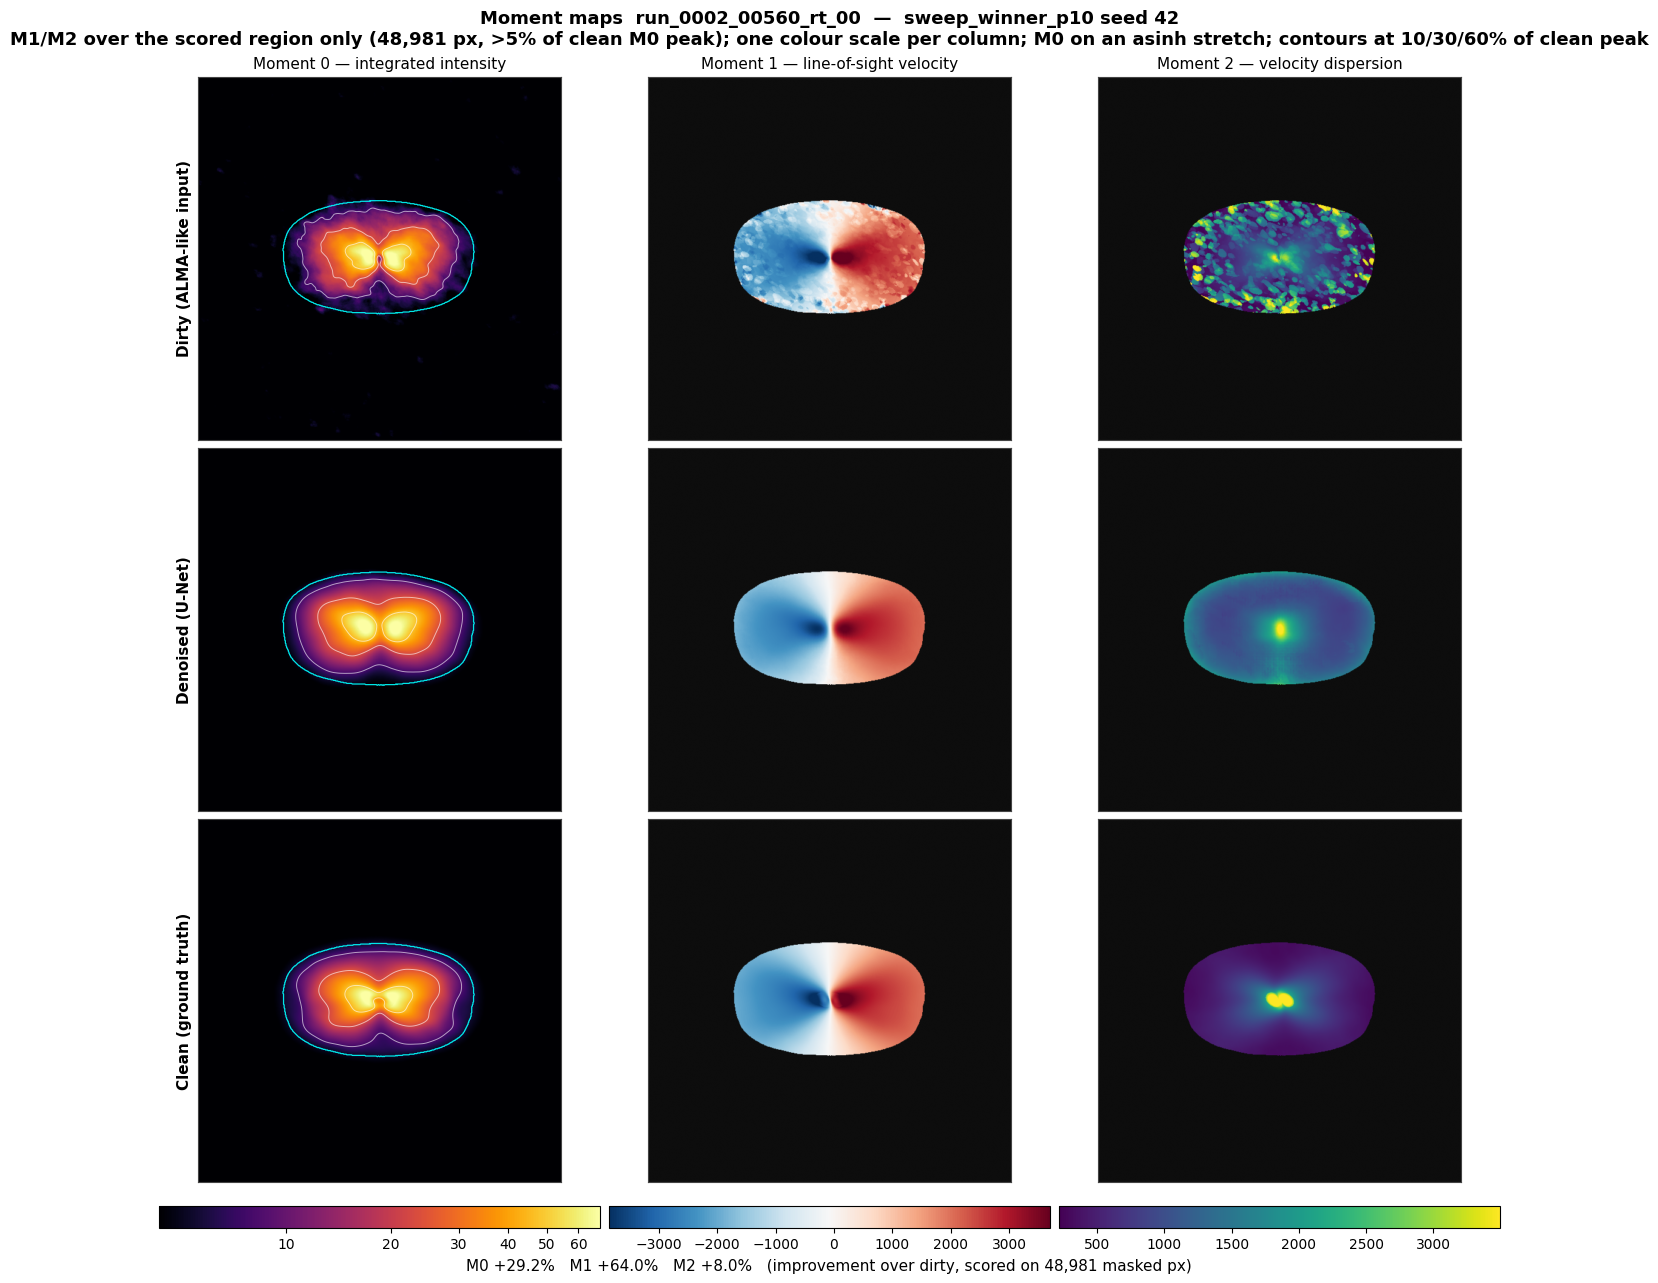

  run_0002_00560_rt_00         M0  +29.2  M1  +64.0  M2   +8.0  -> moments_run_0002_00560_rt_00.png


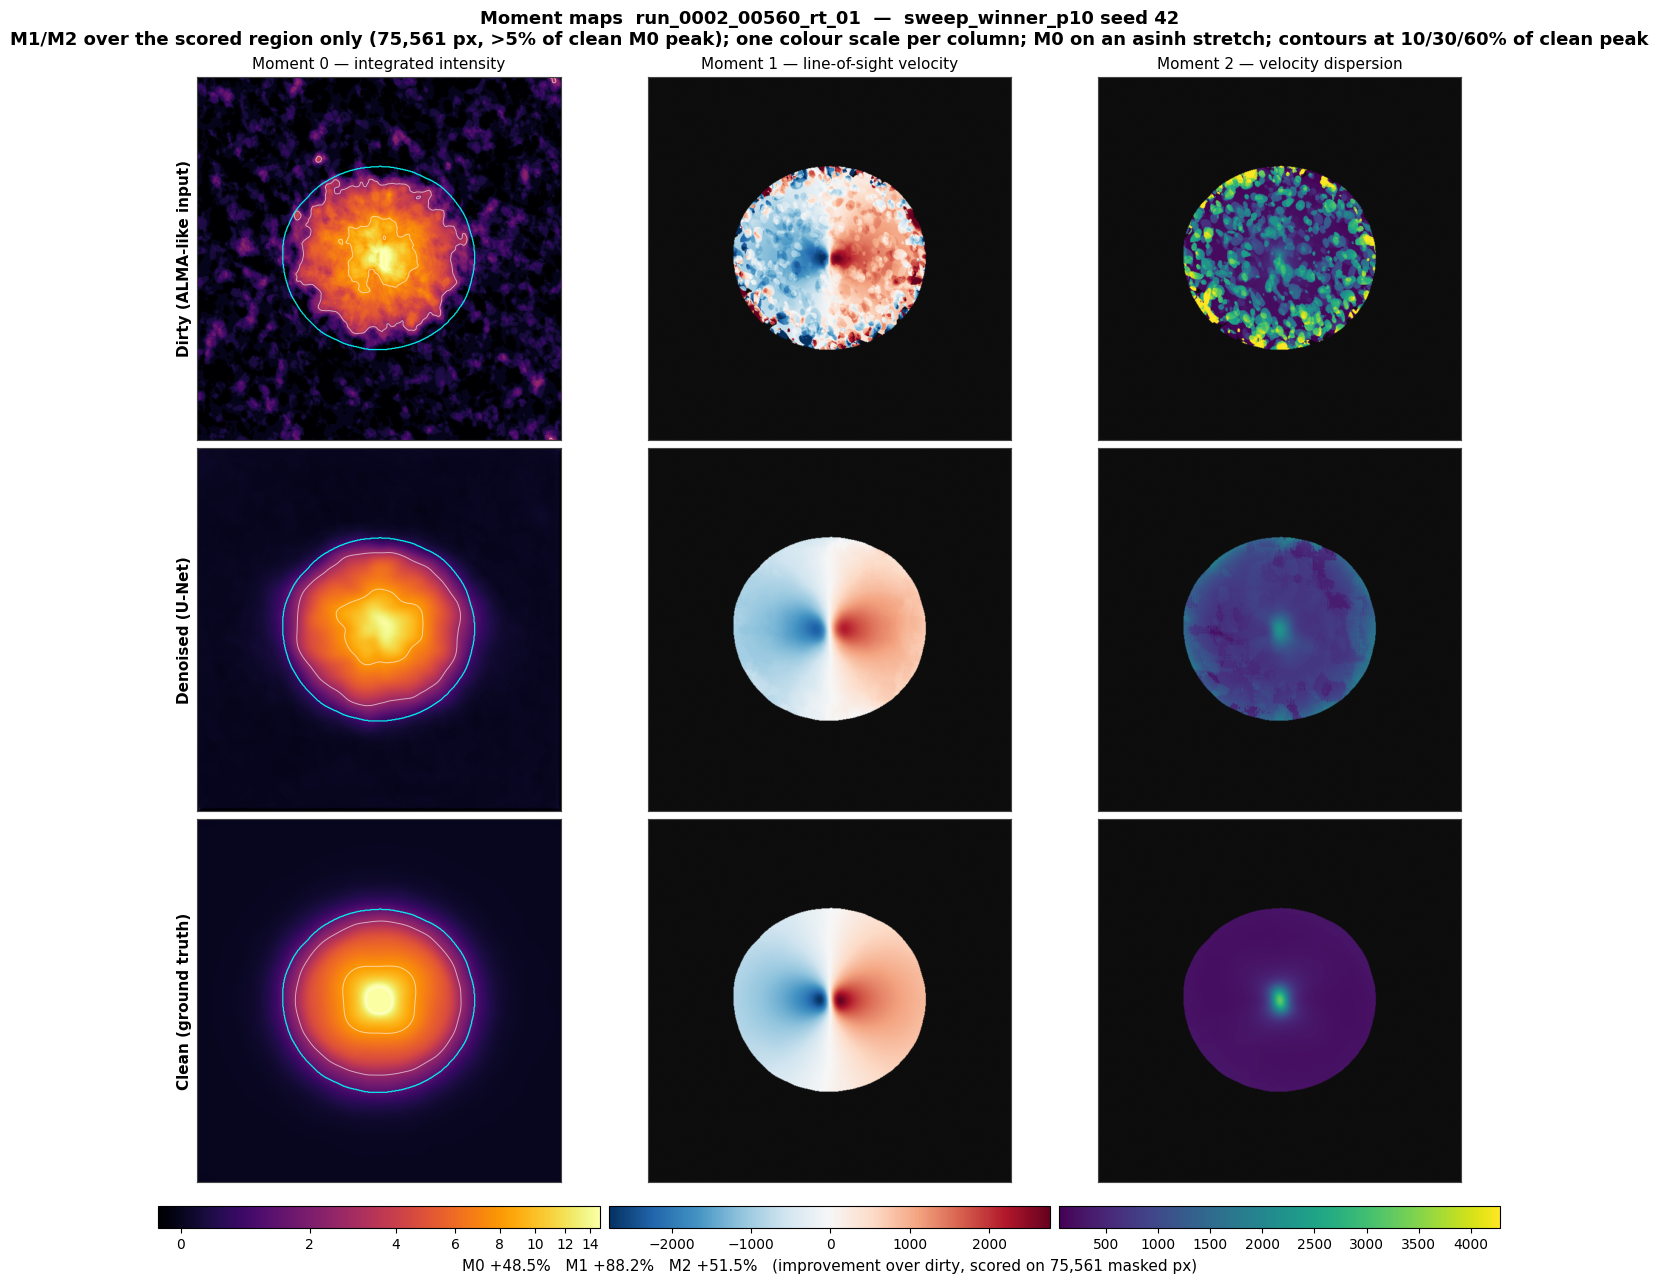

  run_0002_00560_rt_01         M0  +48.5  M1  +88.2  M2  +51.5  -> moments_run_0002_00560_rt_01.png


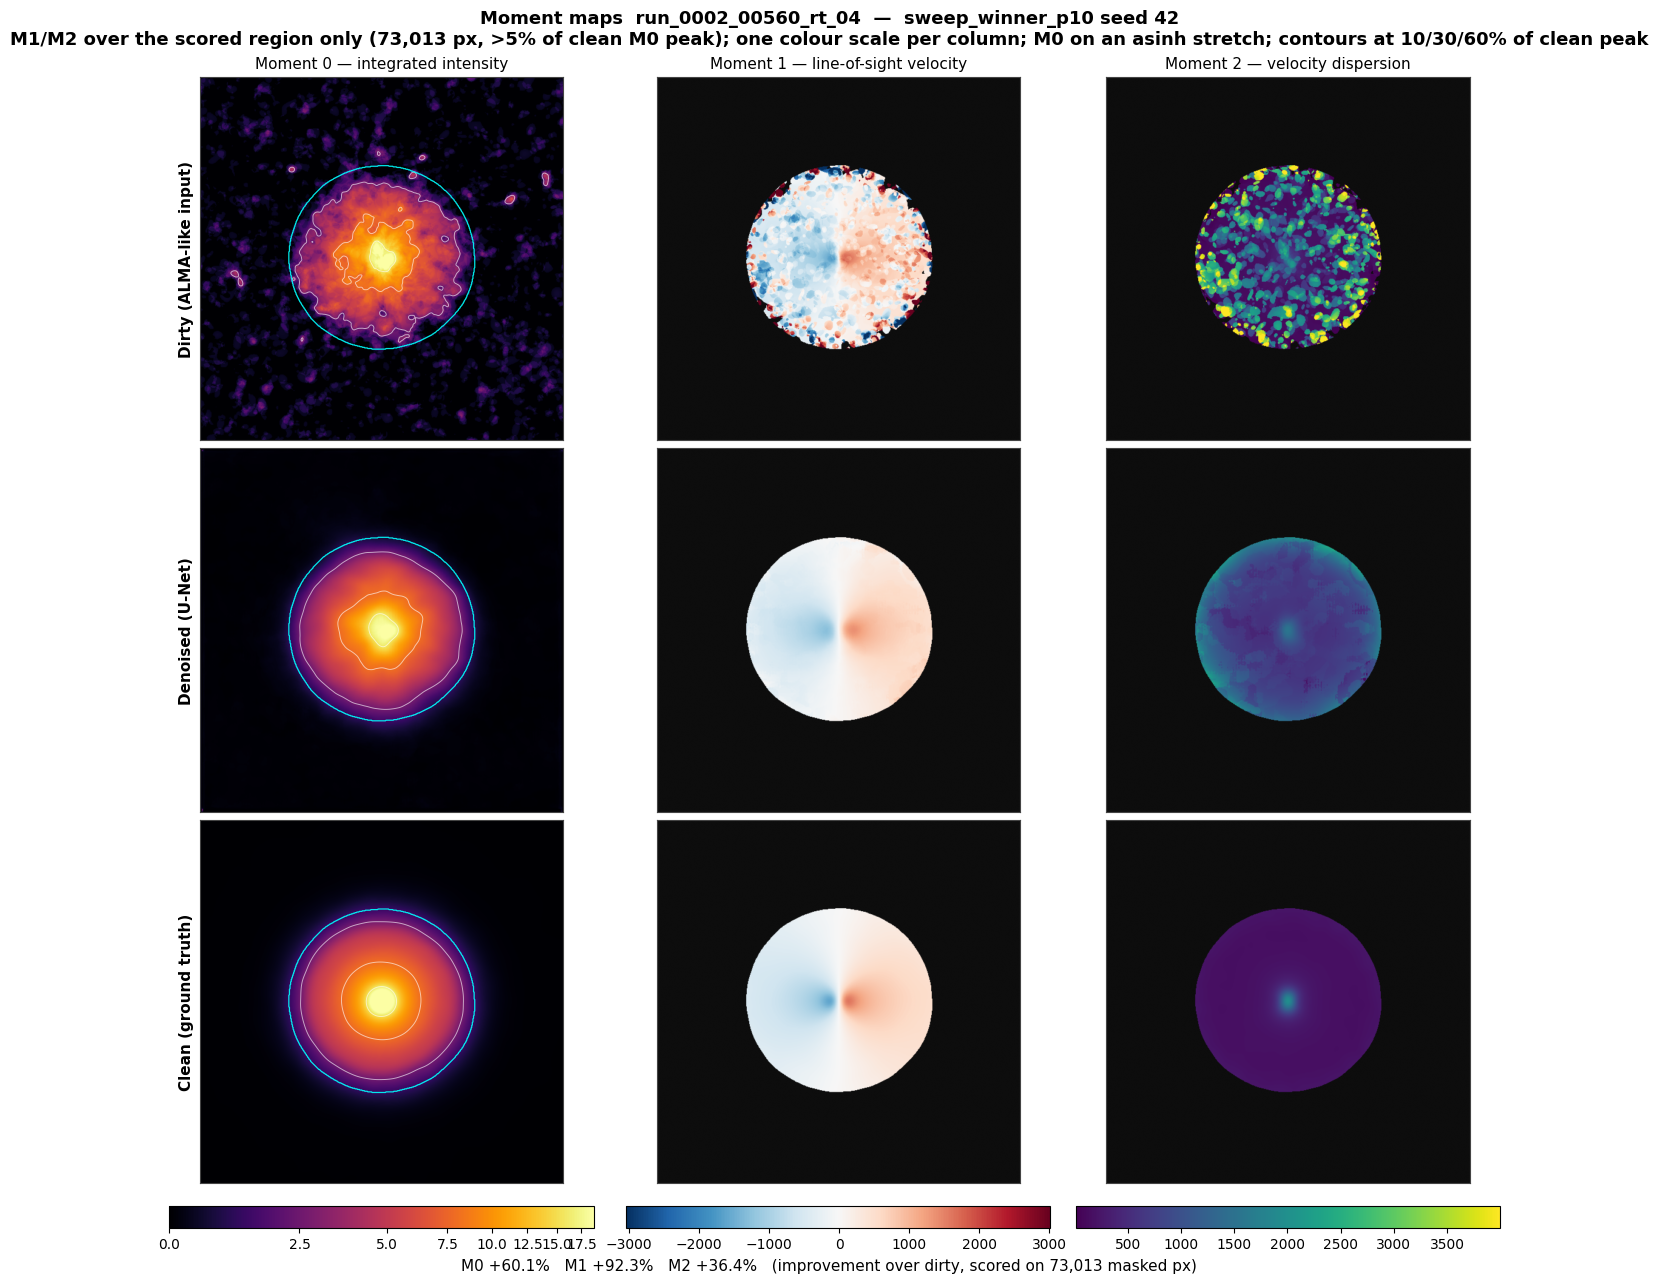

  run_0002_00560_rt_04         M0  +60.1  M1  +92.3  M2  +36.4  -> moments_run_0002_00560_rt_04.png


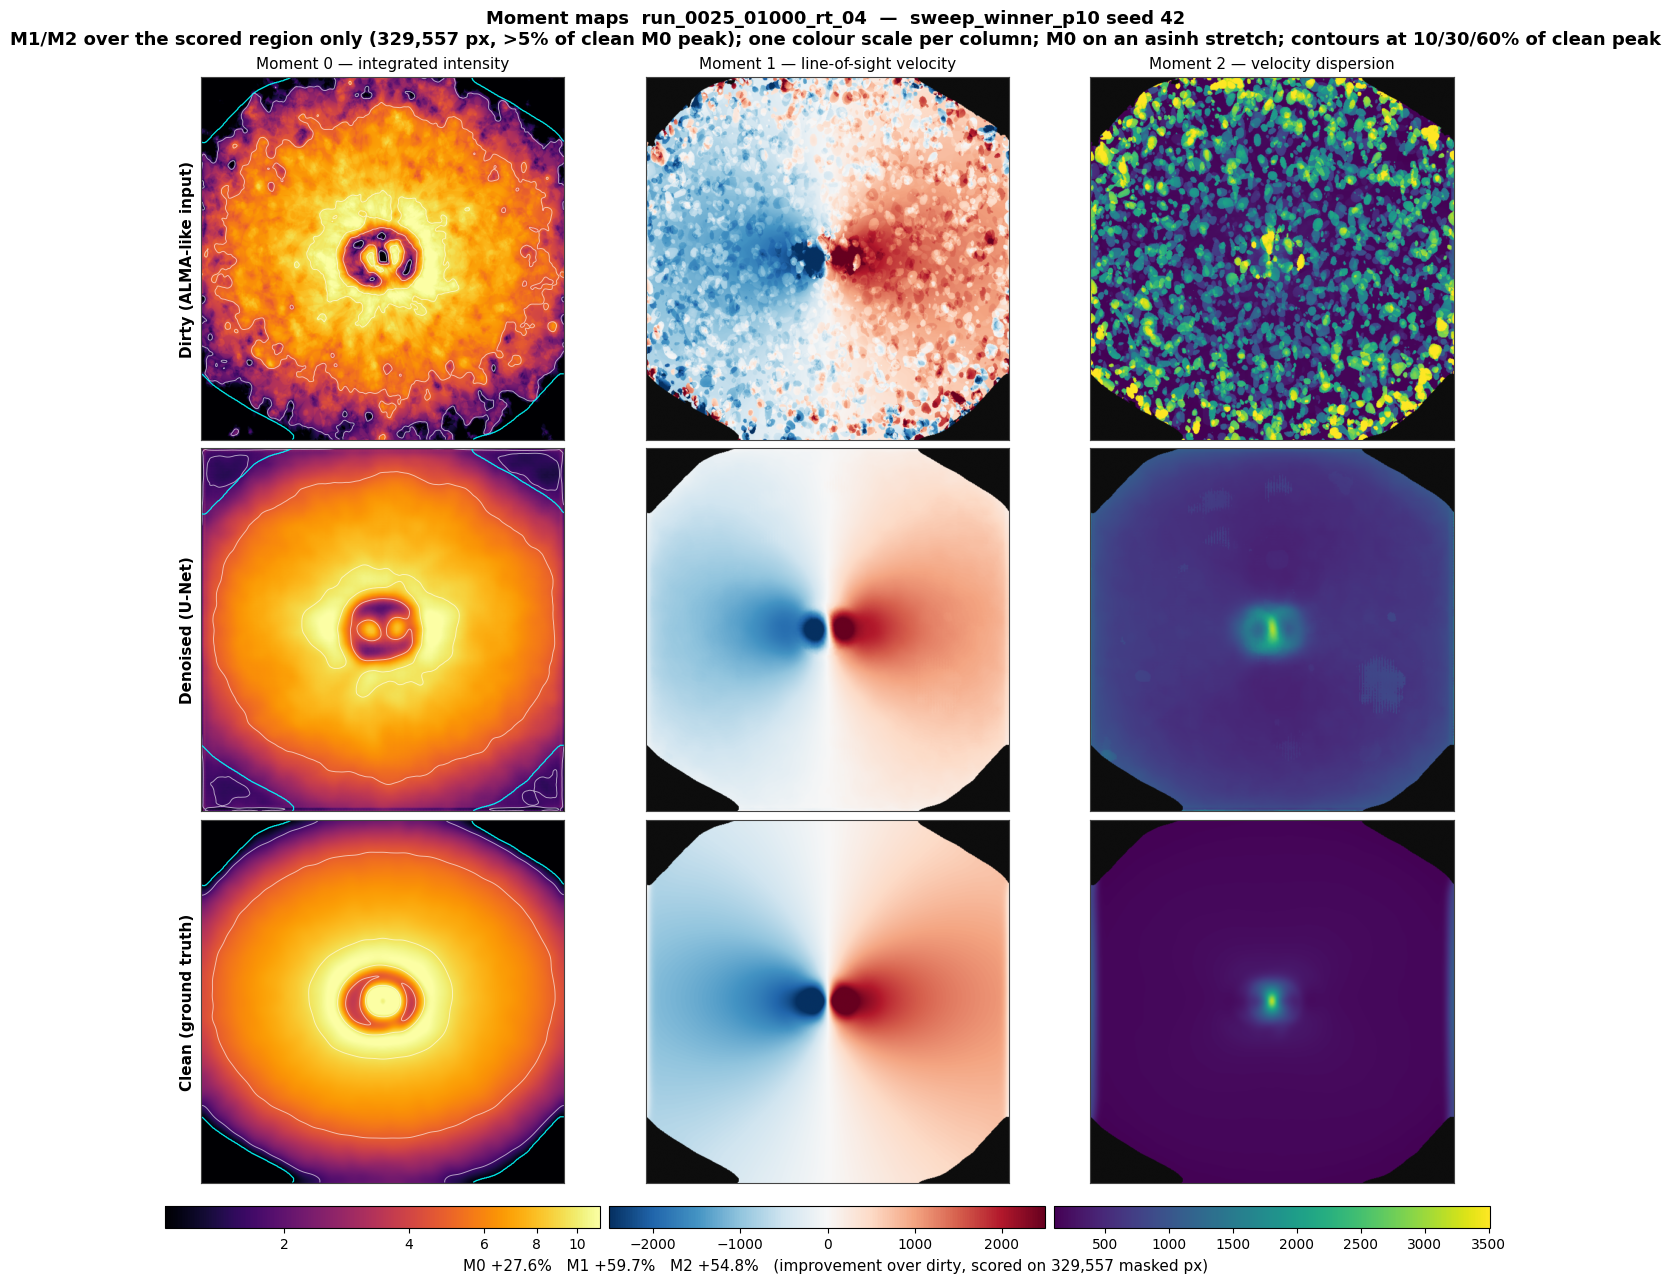

  run_0025_01000_rt_04         M0  +27.6  M1  +59.7  M2  +54.8  -> moments_run_0025_01000_rt_04.png


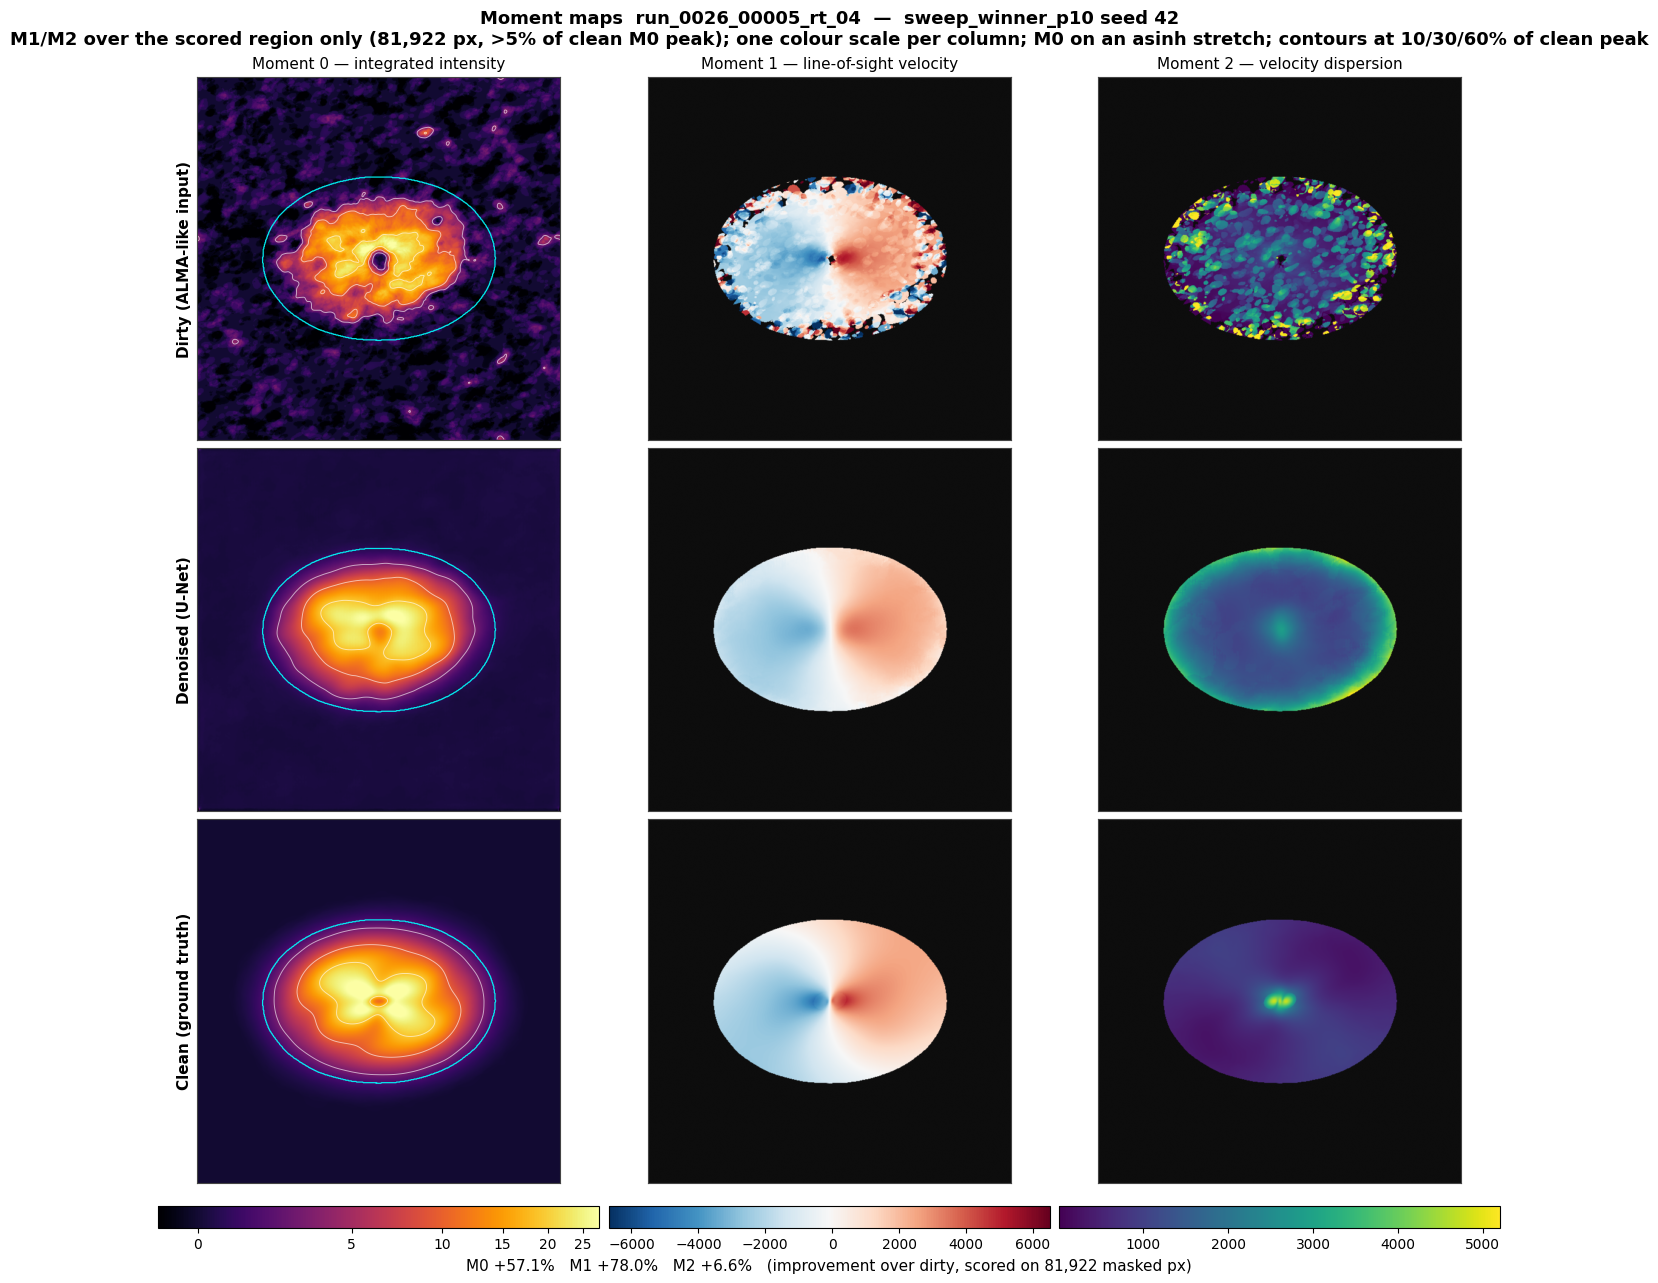

  run_0026_00005_rt_04         M0  +57.1  M1  +78.0  M2   +6.6  -> moments_run_0026_00005_rt_04.png

saved 5 moment-map figures -> ../results/figures


In [9]:
from src.evaluation.moment_maps import plot_moment_comparison

# One figure per holdout cube for the diagnosed checkpoint. `cache` already holds the
# clean/dirty maps; only the denoised pass is new.
FIG_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

moment_figs = []
for ho in holdout_cubes:
    e = cache[ho['folder']]
    den, _ = denoise_cube(ho, eval_net)
    no = generate_moment_maps(None, data_velax=(den, e['velax']))
    imp = moment_improvement(e['clean'], e['dirty'], no)
    tag = '{}  —  {} seed {}'.format(ho['folder'], BEST_CONFIG, BEST_SEED)
    path = os.path.join(FIG_DIR, 'moments_{}.png'.format(ho['folder']))
    fig = plot_moment_comparison(e['clean'], e['dirty'], no, save_path=path, tag=tag)
    fig.text(0.5, -0.012,
             'M0 {:+.1f}%   M1 {:+.1f}%   M2 {:+.1f}%   (improvement over dirty, '
             'scored on {:,} masked px)'.format(imp['M0'], imp['M1'], imp['M2'], imp['n_px']),
             ha='center', fontsize=11)
    plt.show()
    moment_figs.append(path)
    print('  {:<28} M0 {:+6.1f}  M1 {:+6.1f}  M2 {:+6.1f}  -> {}'.format(
        ho['folder'], imp['M0'], imp['M1'], imp['M2'], os.path.basename(path)))
    del den, no

print('\nsaved {} moment-map figures -> {}'.format(len(moment_figs), FIG_DIR))

## 6c. Validation channels: dirty | denoised | clean

[FITSChannelDataset] 2 cubes x ~150 channels = 300 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
channels shared with the DDPM figure:
   run_0016_00550_rt_01 ch 82
   run_0016_00550_rt_01 ch 32
   run_0016_00550_rt_01 ch 177
   run_0016_00550_rt_01 ch 153
   run_0016_00550_rt_01 ch 141


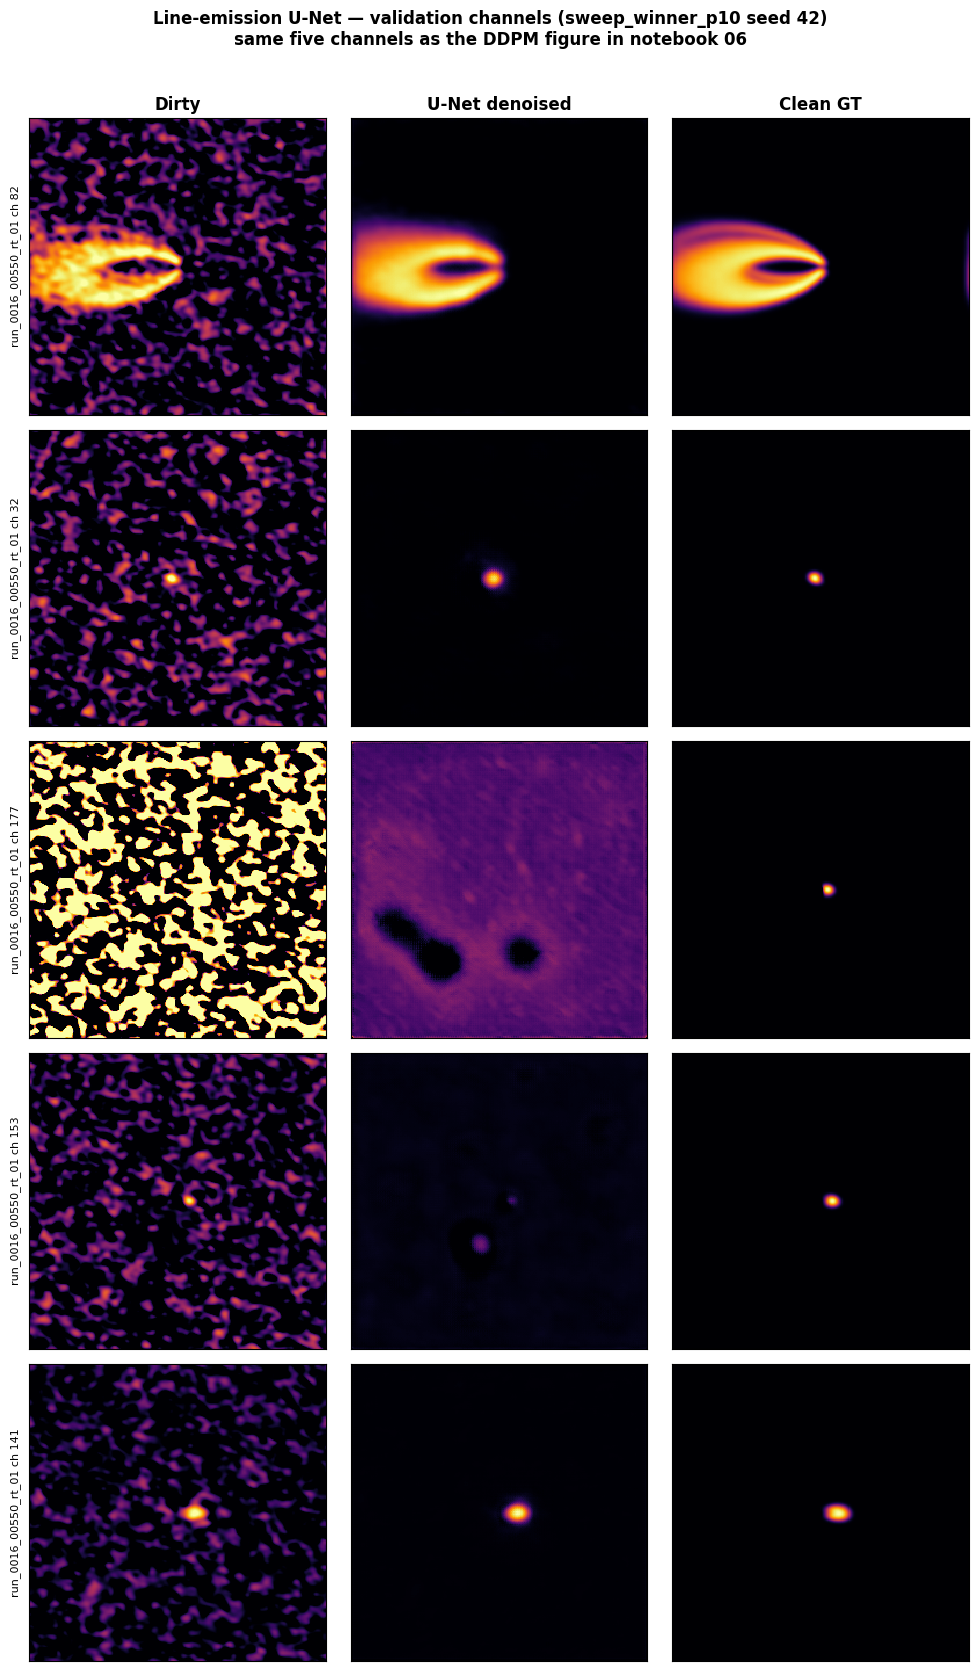

saved -> experiments/line_emission_unet_comparison.png


In [10]:
import random

# The SAME five channels notebook 06 shows for the DDPM, so the two figures are directly
# comparable rather than two random draws.
#
# 06 picks `random.Random(SEED).sample(range(len(val_ds)), 5)` from a val set built with
# N_SAMPLES=150. This notebook now matches that too (05's own N_SAMPLES=256 was a bug --
# 256 > 201 channels per cube, it never ran, fixed in section 3), so val_ds and
# _ddpm_view below already select the same items. Rebuilding it here is redundant but
# kept explicit -- it names the pairing instead of leaving it to coincide silently.
DDPM_N_SAMPLES = 150      # notebook 06's N_SAMPLES; changing it there breaks the pairing

_ddpm_view = FITSChannelDataset(val_cubes, n_samples=DDPM_N_SAMPLES, target_size=TARGET_SIZE,
                                seed=SEED, subtract_continuum=SUBTRACT_CONTINUUM,
                                continuum_n=CONTINUUM_N)
_idxs = random.Random(SEED).sample(range(len(_ddpm_view)), 5)
print('channels shared with the DDPM figure:')
for _i in _idxs:
    _ci, _ch = _ddpm_view.index[_i]
    print('   {} ch {}'.format(_ddpm_view.cube_paths[_ci][2], _ch))
# plot_channel_triptych (src/evaluation/moment_maps.py) replaces a hand-rolled per-row
# imshow that had no guard for a near-empty validation channel: when clean is nearly
# constant, vmin~=vmax collapses the whole row to inferno(0.5) -- a solid magenta-pink
# panel instead of black. It hit this exact figure in production. The shared function also
# asinh-stretches (so the background reads black without crushing faint structure) and is
# used identically by notebook 06, so the two figures are visually comparable, not just
# channel-matched.
from src.evaluation.moment_maps import plot_channel_triptych

_triptych_rows = []
with torch.no_grad():
    for ix in _idxs:
        d, c = _ddpm_view[ix]
        pred = eval_net(d[None].to(device),
                        torch.zeros(1, dtype=torch.long, device=device))[0, 0].cpu().numpy()
        cl = c[0].numpy()
        ci, ch = _ddpm_view.index[ix]
        _triptych_rows.append((d[0].numpy(), pred, cl,
                               '{} ch {}'.format(_ddpm_view.cube_paths[ci][2], ch)))

fig = plot_channel_triptych(
    _triptych_rows, model_label='U-Net denoised',
    title='Line-emission U-Net — validation channels ({} seed {})\n'
          'same five channels as the DDPM figure in notebook 06'.format(BEST_CONFIG, BEST_SEED),
    save_path='../experiments/line_emission_unet_comparison.png')
plt.show()
print('saved -> experiments/line_emission_unet_comparison.png')

## 6d. Every arm vs V12: the headline figure

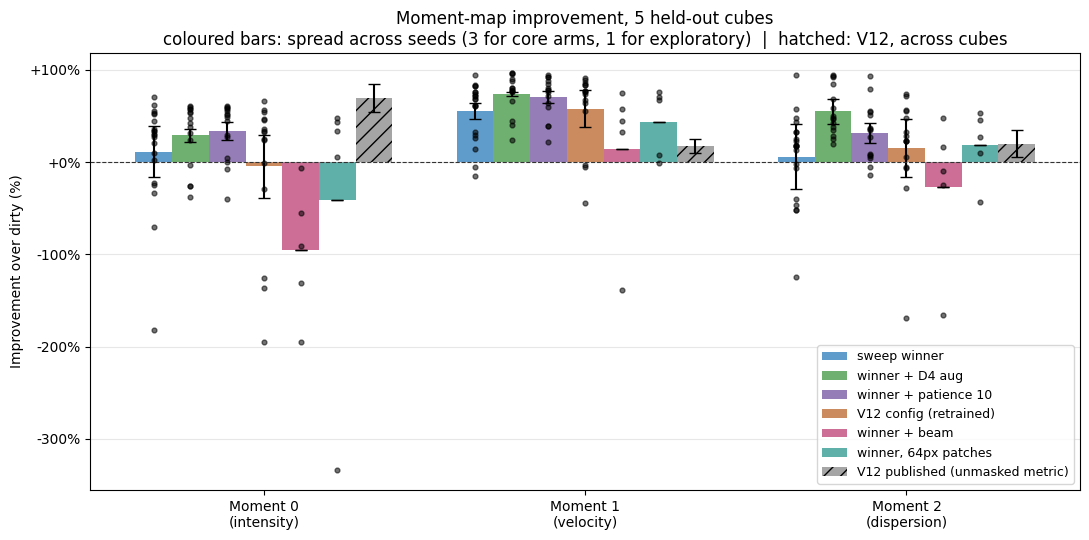

saved -> results/moment_all_arms_vs_v12.png


In [11]:
import matplotlib.ticker as mticker

_arms = [n for n in CONFIGS if n in band_mom]
_labels = {'sweep_winner': 'sweep winner', 'sweep_winner_aug': 'winner + D4 aug',
           'sweep_winner_p10': 'winner + patience 10', 'v12_cfg': 'V12 config (retrained)',
           'winner_beam': 'winner + beam', 'winner_patch': 'winner, 64px patches',
           'winner_native600': 'winner, native 600px'}
_colors = {'sweep_winner': '#4E91C7', 'sweep_winner_aug': '#5FA860',
           'sweep_winner_p10': '#8A6FB0', 'v12_cfg': '#C77E4E',
           'winner_beam': '#C75E8A', 'winner_patch': '#4EA8A0', 'winner_native600': '#B0913F'}

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(moments))
w_ = 0.8 / (len(_arms) + 1)
for k, name in enumerate(_arms):
    off = (k - len(_arms) / 2) * w_
    ax.bar(x + off, [band_mom[name][m][0] for m in moments], w_,
           yerr=[band_mom[name][m][1] for m in moments], capsize=4,
           label=_labels.get(name, name), color=_colors.get(name, '#888888'), alpha=0.9)
    for i, m in enumerate(moments):
        pts = [float(r[f'imp_{m}']) for sd in seeds_for(name)
               for r in per_run.get((name, sd), [])]
        if pts:
            ax.scatter([i + off] * len(pts), pts, color='k', s=12, zorder=5, alpha=0.55)
# V12 published, on the ORIGINAL unmasked metric -- hatched so it cannot be misread as
# one of the like-for-like bars beside it.
off = (len(_arms) - len(_arms) / 2) * w_
ax.bar(x + off, [V12[m][0] for m in moments], w_, yerr=[V12[m][1] for m in moments],
       capsize=4, label='V12 published (unmasked metric)', color='#9B9B9B', alpha=0.9,
       hatch='//')
ax.axhline(0, color='#333333', lw=0.8, ls='--')
ax.set_xticks(x)
ax.set_xticklabels(['Moment 0\n(intensity)', 'Moment 1\n(velocity)', 'Moment 2\n(dispersion)'])
ax.set_ylabel('Improvement over dirty (%)')
ax.set_title('Moment-map improvement, 5 held-out cubes\n'
             'coloured bars: spread across seeds ({} for core arms, 1 for exploratory)  |  '
             'hatched: V12, across cubes'.format(len(SEEDS)))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'moment_all_arms_vs_v12.png'), dpi=140, bbox_inches='tight')
plt.show()
print('saved -> results/moment_all_arms_vs_v12.png')

## 7. Artifact diagnostics: peak overshoot + low-SNR invented structure

validation channels analysed: 300

PEAK OVERSHOOT  denoised.max / clean.max   (1.0 = perfect; prior ch-100 figure 1.151)
  mean 1.418 | median 0.848 | p90 1.054 | max 91.580
  channels overshooting by >10%: 8%

NEGATIVE FLOOR LEAK  denoised.min  (clean floor ~0; prior figure -0.0017)
  mean -0.13108 | most negative -0.21807

INVENTED STRUCTURE  (background pixels pushed above 20% of clean peak, blobs >= 20 px)
  channels with >=1 fake blob: 33% | blobs/channel 0.97
  mean invented area fraction of background: 6.6486% | worst channel: 99.9587%

  SNR split at median 3.9  ->  is invented structure low-SNR specific?
    low-SNR  half: blobs/channel 1.63 | invented area 13.2590% | overshoot 1.992
    high-SNR half: blobs/channel 0.31 | invented area 0.0382% | overshoot 0.844

per-channel diagnostics saved -> ../results/artifact_diagnostics_sweepwinner.csv


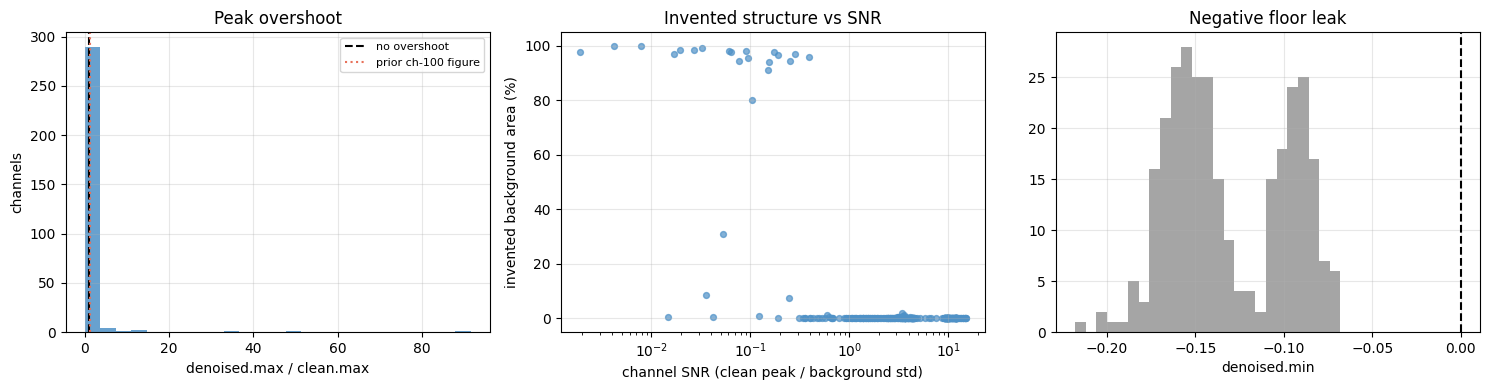

In [12]:
from src.evaluation.artifacts import channel_artifacts, summarise, INVENT_FRAC, BLOB_MIN_PX

eval_net.eval()
rows = []
with torch.no_grad():
    for ix in range(len(val_ds)):
        d, c = val_ds[ix]
        pred = eval_net(d[None].to(device),
                        torch.zeros(1, dtype=torch.long, device=device))[0, 0].cpu().numpy()
        cl, dt = c[0].numpy(), d[0].numpy()
        if float(cl.max()) <= 0:
            continue                      # empty channel: nothing to score against
        ci, ch = val_ds.index[ix]
        rows.append({'cube': val_ds.cube_paths[ci][2], 'channel': int(ch),
                     **channel_artifacts(cl, dt, pred)})

s = summarise(rows)
print('validation channels analysed:', s['n_channels'])
print('\nPEAK OVERSHOOT  denoised.max / clean.max   (1.0 = perfect; prior ch-100 figure 1.151)')
print('  mean {overshoot_mean:.3f} | median {overshoot_median:.3f} | p90 {overshoot_p90:.3f} | max {overshoot_max:.3f}'.format(**s))
print('  channels overshooting by >10%: {:.0f}%'.format(100 * s['frac_over_10pct']))
print('\nNEGATIVE FLOOR LEAK  denoised.min  (clean floor ~0; prior figure -0.0017)')
print('  mean {floor_leak_mean:+.5f} | most negative {floor_leak_min:+.5f}'.format(**s))
print('\nINVENTED STRUCTURE  (background pixels pushed above {:.0%} of clean peak,'
      ' blobs >= {} px)'.format(INVENT_FRAC, BLOB_MIN_PX))
print('  channels with >=1 fake blob: {:.0f}% | blobs/channel {:.2f}'.format(
    100 * s['frac_channels_with_blob'], s['blobs_per_channel']))
print('  mean invented area fraction of background: {invented_frac_mean:.4%} |'
      ' worst channel: {invented_frac_max:.4%}'.format(**s))

if 'snr_median' in s:
    print('\n  SNR split at median {snr_median:.1f}  ->  is invented structure low-SNR specific?'.format(**s))
    print('    low-SNR  half: blobs/channel {low_snr_blobs_per_channel:.2f} |'
          ' invented area {low_snr_invented_frac:.4%} | overshoot {low_snr_overshoot:.3f}'.format(**s))
    print('    high-SNR half: blobs/channel {high_snr_blobs_per_channel:.2f} |'
          ' invented area {high_snr_invented_frac:.4%} | overshoot {high_snr_overshoot:.3f}'.format(**s))

ov   = np.array([r['overshoot'] for r in rows])
leak = np.array([r['floor_leak'] for r in rows])
inv   = np.array([r['invented_frac'] for r in rows])
snr  = np.array([r['snr'] for r in rows])

diag_csv = os.path.join(OUT_DIR, 'artifact_diagnostics_sweepwinner.csv')
with open(diag_csv, 'w', newline='') as cf:
    # Columns come from the data, not a hand-kept list. channel_artifacts() also returns
    # n_background_px, which this list omitted, so DictWriter raised "dict contains fields
    # not in fieldnames" AFTER the entire diagnostic had already run. The fixed names hold
    # the column order; anything new is appended instead of crashing the write.
    # n_background_px matters especially: RULES.md #8 exists because a zero here was once
    # read as a clean result when the detector could not fire.
    _fixed = ['cube', 'channel', 'snr', 'overshoot', 'floor_leak',
              'invented_frac', 'invented_blobs']
    _extra = [k for k in rows[0] if k not in _fixed] if rows else []
    w = csv.DictWriter(cf, fieldnames=_fixed + _extra)
    w.writeheader()
    for r in rows: w.writerow(r)
print('\nper-channel diagnostics saved ->', diag_csv)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(ov, bins=25, color='#4E91C7', alpha=0.85)
ax[0].axvline(1.0, color='k', ls='--', label='no overshoot')
ax[0].axvline(1.151, color='#E8715A', ls=':', label='prior ch-100 figure')
ax[0].set_xlabel('denoised.max / clean.max'); ax[0].set_ylabel('channels')
ax[0].set_title('Peak overshoot'); ax[0].legend(fontsize=8)
ax[1].scatter(snr, inv * 100, s=18, alpha=0.7, color='#4E91C7')
ax[1].set_xlabel('channel SNR (clean peak / background std)')
ax[1].set_ylabel('invented background area (%)')
ax[1].set_title('Invented structure vs SNR'); ax[1].set_xscale('log')
ax[2].hist(leak, bins=25, color='#9B9B9B', alpha=0.9)
ax[2].axvline(0.0, color='k', ls='--')
ax[2].set_xlabel('denoised.min'); ax[2].set_title('Negative floor leak')
for a in ax: a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'artifact_diagnostics_sweepwinner.png'), dpi=140); plt.show()

## 8. Worst offenders: visual check of the invented structure

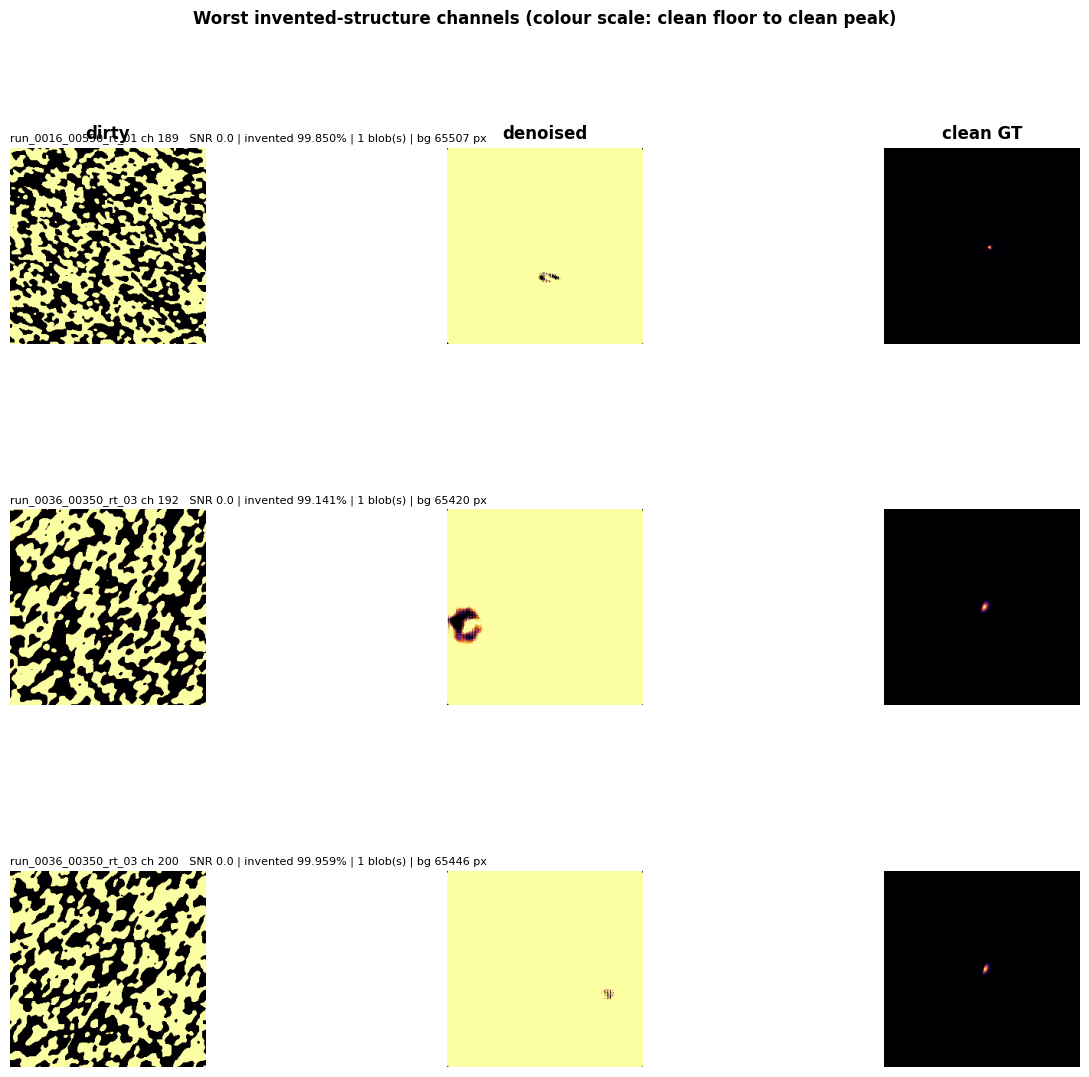

saved -> experiments/hallucination_worst_channels.png


In [13]:
# Rank by invented structure, then show the worst channels.
#
# Four things were wrong here and all trace to the same assumption -- that the clean
# background sits near zero, which is false under shared dirty-scale normalisation:
#
#   1. every invented_frac was 0.0 (empty background mask), so the sort was a no-op
#      and this simply showed the FIRST three channels -- which is why all three came
#      from one cube and were labelled "worst".
#   2. SNR printed as nan for the same reason.
#   3. the row label was drawn with set_title on the same axes that already carried
#      the 'dirty' column header, so the two strings overlapped.
#   4. the colour scale ran vmin=0..clean.max(), but the data floor is ~+0.32, so a
#      third of the ramp was spent below any real pixel and every panel washed out.
#
# Ranking now breaks ties on overshoot and spreads picks across cubes, so a degenerate
# metric can never again masquerade as a considered selection.
def _rank(r):
    return (-r['invented_frac'], -r.get('invented_blobs', 0), -abs(r['overshoot'] - 1.0))

ordered = sorted(rows, key=_rank)
if all(r['invented_frac'] == 0 for r in rows):
    print('NOTE: no channel scored any invented structure -- showing the largest '
          'overshoot instead, and check n_background_px before trusting this.')

seen_cubes, worst = set(), []
for r in ordered:                      # prefer distinct cubes before repeating one
    if r['cube'] not in seen_cubes:
        worst.append(r); seen_cubes.add(r['cube'])
    if len(worst) == 3:
        break
for r in ordered:
    if len(worst) == 3:
        break
    if r not in worst:
        worst.append(r)

key = {(r['cube'], r['channel']) for r in worst}
picks = [ix for ix in range(len(val_ds))
         if (val_ds.cube_paths[val_ds.index[ix][0]][2], int(val_ds.index[ix][1])) in key][:3]

fig, ax = plt.subplots(len(picks), 3, figsize=(11, 3.9 * len(picks)), squeeze=False)
with torch.no_grad():
    for r, ix in enumerate(picks):
        d, c = val_ds[ix]
        pred = eval_net(d[None].to(device),
                        torch.zeros(1, dtype=torch.long, device=device))[0, 0].cpu().numpy()
        cl = c[0].numpy()
        # floor-relative window: the background is NOT at 0, so anchoring vmin there
        # throws away most of the colour range
        floor = float(np.percentile(cl, 1)); vmax = float(cl.max())
        ci, ch = val_ds.index[ix]
        info = next(q for q in rows
                    if q['cube'] == val_ds.cube_paths[ci][2] and q['channel'] == int(ch))
        for col, im in enumerate([d[0].numpy(), pred, cl]):
            ax[r][col].imshow(im, cmap='inferno', vmin=floor, vmax=vmax)
            ax[r][col].axis('off')
            if r == 0:      # column headers on the top row only
                ax[r][col].set_title(['dirty', 'denoised', 'clean GT'][col], fontweight='bold')
        snr = info['snr']
        snr_s = f'{snr:.1f}' if np.isfinite(snr) else 'n/a'
        # row label as figure text to the LEFT of the axes -- never a title, so it
        # cannot collide with the column headers
        ax[r][0].text(0.0, 1.02,
                      '{} ch {}   SNR {} | invented {:.3%} | {} blob(s) | bg {} px'.format(
                          val_ds.cube_paths[ci][2], ch, snr_s, info['invented_frac'],
                          info['invented_blobs'], info.get('n_background_px', '?')),
                      transform=ax[r][0].transAxes, fontsize=8, va='bottom', ha='left')

fig.suptitle('Worst invented-structure channels (colour scale: clean floor to clean peak)',
             fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
os.makedirs('../experiments', exist_ok=True)
plt.savefig('../experiments/hallucination_worst_channels.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved -> experiments/hallucination_worst_channels.png')

## 9. Persist artifacts to /kaggle/working (survives session end)

In [14]:
import glob

# RULES.md #1: the per-model saves already happened in section 4, as each model finished.
# This is the backstop for everything else, and for a session that resumed from CSVs
# without retraining.
if ON_KAGGLE:
    n_ck = n_res = 0
    for _src in sorted(glob.glob(os.path.join(CKPT_DIR, '*.pth'))):
        _dst = os.path.join('/kaggle/working', os.path.basename(_src))
        if not os.path.exists(_dst):
            shutil.copy2(_src, _dst)
        n_ck += 1
    for _dir in (OUT_DIR, '../experiments'):
        for _pat in ('*.csv', '*.png', '*.npz'):
            for _src in sorted(glob.glob(os.path.join(_dir, _pat))):
                shutil.copy2(_src, os.path.join('/kaggle/working', os.path.basename(_src)))
                n_res += 1
    print('persisted {} checkpoint(s) and {} result file(s) to /kaggle/working'.format(
        n_ck, n_res))
    if n_ck == 0:
        print('  WARNING: no checkpoints in ' + CKPT_DIR)
    print('\nTo resume: Add Input -> Notebooks -> THIS notebook. Do NOT re-upload a .pth as')
    print('a Dataset -- Kaggle unpacks it and torch.load then fails with "Is a directory".')
else:
    print('not on Kaggle -- nothing to persist')

persisted 15 checkpoint(s) and 15 result file(s) to /kaggle/working

To resume: Add Input -> Notebooks -> THIS notebook. Do NOT re-upload a .pth as
a Dataset -- Kaggle unpacks it and torch.load then fails with "Is a directory".


## Collect this notebook's outputs

In [15]:
from src.evaluation.collect_outputs import collect_outputs

# Checkpoints are NOT listed: section 9 already puts them at the top of /kaggle/working,
# and this collector writes into /kaggle/working/outputs -- naming them would duplicate
# nine models inside the same Output.
_run_dir = collect_outputs(
    '05-unet-line-emission',
    [
        'nb05_seed_repeats.csv',                 # section 4: PSNR per config per seed
        'nb05_moment_by_seed.csv',               # section 6: moments per checkpoint
        'moment_all_arms_vs_v12.png',            # section 6d: the headline figure
        'moment_map_holdout_summary_sweepwinner.csv',
        'artifact_diagnostics_sweepwinner.csv',
        'artifact_diagnostics_sweepwinner.png',
        'hallucination_worst_channels.png',      # section 8
        'line_emission_unet_comparison.png',     # section 6c
        'sweepwinner_loss.png',                  # section 5
        'moments_*.png',                         # section 6b, one per holdout cube
    ],
    extra={'configs': sorted(CONFIGS), 'seeds': SEEDS, 'best': f'{BEST_CONFIG} seed {BEST_SEED}',
           'target_size': TARGET_SIZE, 'n_samples': N_SAMPLES,
           'metric': 'signal-masked + noise-clipped (moment_improvement)'},
)
print('\nAnything listed as NOT FOUND above did not get written this run.')

collected 14 file(s), 9.4 MiB -> /kaggle/working/outputs/05-unet-line-emission/2026-08-16T150210_6f5c798
       0.03 MiB  artifact_diagnostics_sweepwinner.csv
       0.08 MiB  artifact_diagnostics_sweepwinner.png
       0.24 MiB  hallucination_worst_channels.png
       0.87 MiB  line_emission_unet_comparison.png
       0.11 MiB  moment_all_arms_vs_v12.png
       0.00 MiB  moment_map_holdout_summary_sweepwinner.csv
       0.79 MiB  moments_run_0002_00560_rt_00.png
       1.40 MiB  moments_run_0002_00560_rt_01.png
       1.47 MiB  moments_run_0002_00560_rt_04.png
       2.64 MiB  moments_run_0025_01000_rt_04.png
       1.69 MiB  moments_run_0026_00005_rt_04.png
       0.01 MiB  nb05_moment_by_seed.csv
       0.00 MiB  nb05_seed_repeats.csv
       0.05 MiB  sweepwinner_loss.png

Anything listed as NOT FOUND above did not get written this run.
